In [ ]:
import datetime
import pandas as pd
from scipy.io import loadmat
from pandas import DataFrame
import keras

In [ ]:
print("Input which battery you need to extract data from. Choose from the following")
print("Battery Number: B0005,B0006,B0007,B0018")
B = input()

Input which battery you need to extract data from. Choose from the following
Battery Number: B0005,B0006,B0007,B0018
B0005


In [37]:
def to_df(mat_db):
    """Returns one pd.DataFrame per cycle type"""

    # Features common for every cycle
    cycles_cols = ['type', 'ambient_temperature', 'time']

    # Features monitored during the cycle
    features_cols = {
        'charge': ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                'Current_charge', 'Voltage_charge', 'Time'],
        'discharge': ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                    'Current_charge', 'Voltage_charge', 'Time', 'Capacity'],
        'impedance': ['Sense_current', 'Battery_current', 'Current_ratio',
                    'Battery_impedance', 'Rectified_impedance', 'Re', 'Rct']
    }

    # Define one pd.DataFrame per cycle type
    df = {key: pd.DataFrame() for key in features_cols.keys()}

    # Get every cycle
    print(f'Number of cycles: {mat_db[0][0][0].shape[1]}')
    cycles = [[row.flat[0] for row in line] for line in mat_db[0][0][0][0]]

    # Get measures for every cycle
    for cycle_id, cycle_data in enumerate(cycles):
        tmp = pd.DataFrame()

        # Data series for every cycle
        features_x_cycle = cycle_data[-1]

        # Get features for the specific cycle type
        features = features_cols[cycle_data[0]]

        for feature, data in zip(features, features_x_cycle):
            if len(data[0]) > 1:
                # Correct number of records
                tmp[feature] = data[0]
            else:
                # Single value, so assign it to all rows
                tmp[feature] = data[0][0]

        # Add columns common to the cycle measurements
        tmp['id_cycle'] = cycle_id
        for k, col in enumerate(cycles_cols):
            tmp[col] = cycle_data[k]

        # Append cycle data to the right pd.DataFrame
        cycle_type = cycle_data[0]
        df[cycle_type] = df[cycle_type].append(tmp, ignore_index=True)

    return df

In [38]:
mat_db = loadmat(B+'.mat') [B]
dfs = to_df(mat_db)

dfs["charge"].to_csv("charge_"+B+".csv")
dfs["discharge"].to_csv("discharge_"+B+".csv")
chdf=dfs["charge"]
disdf=dfs["discharge"]

Number of cycles: 616


<ipython-input-37-ab2235dd5e61>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df[cycle_type] = df[cycle_type].append(tmp, ignore_index=True)
<ipython-input-37-ab2235dd5e61>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df[cycle_type] = df[cycle_type].append(tmp, ignore_index=True)
<ipython-input-37-ab2235dd5e61>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df[cycle_type] = df[cycle_type].append(tmp, ignore_index=True)
<ipython-input-37-ab2235dd5e61>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df[cycle_type] = df[cycle_type].append(tmp, ignore_index=True)
<ipython-input-37-ab2235dd5e61>:49: FutureWarning: The frame.app

**Current and Voltage during Charging Process-**

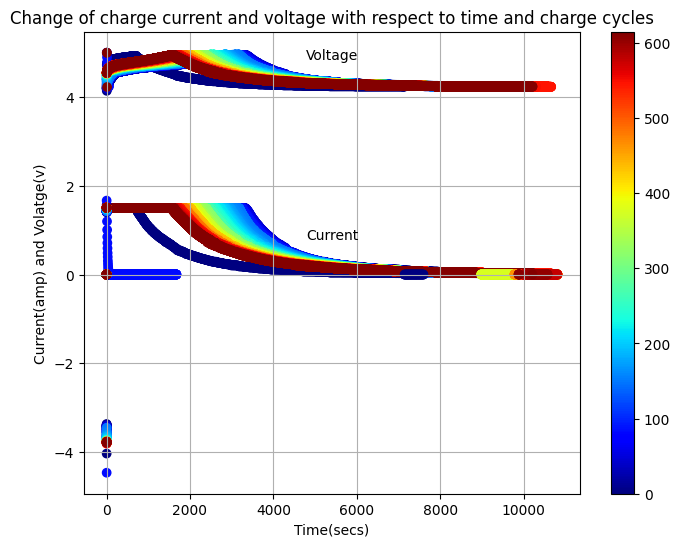

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Plotting the 2D graph
plt.figure(figsize=(8, 6))
plt.scatter(chdf['Time'], chdf['Current_charge'],label='Current', c=chdf['id_cycle'], cmap='jet')  # Color-coded scatter plot
plt.scatter(chdf['Time'], chdf['Voltage_charge'],label='Voltage', c=chdf['id_cycle'], cmap='jet')
plt.xlabel('Time(secs)')
plt.ylabel('Current(amp) and Volatge(v)')
plt.title('Change of charge current and voltage with respect to time and charge cycles')
current_label = 'Current'
voltage_label = 'Voltage'
plt.text(0.5, 0.55, current_label, transform=plt.gca().transAxes, ha='center')
plt.text(0.5, 0.94, voltage_label, transform=plt.gca().transAxes, ha='center')
plt.colorbar()  # Add a colorbar to indicate the third attribute
plt.grid(True)
plt.show()

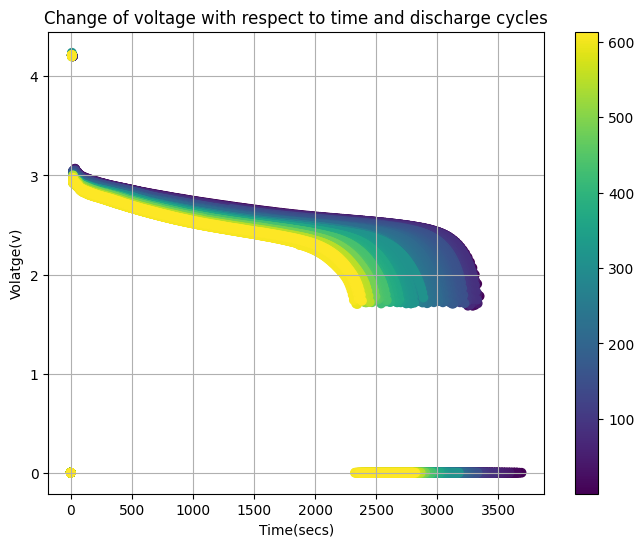

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the 2D graph
plt.figure(figsize=(8, 6))
plt.scatter(disdf['Time'], disdf['Voltage_charge'], c=disdf['id_cycle'], cmap='viridis')  # Color-coded scatter plot
plt.xlabel('Time(secs)')
plt.ylabel('Volatge(v)')
plt.title('Change of voltage with respect to time and discharge cycles')
plt.colorbar()  # Add a colorbar to indicate the third attribute
plt.grid(True)
plt.show()


**Extracting Features of battery (capacity, temperature,IC peak and position of charging/discharging data-**

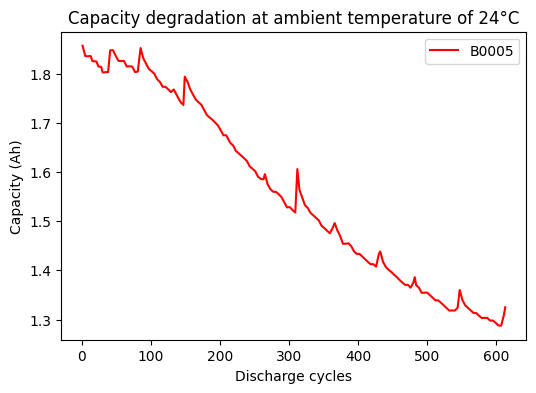

In [ ]:
# load .mat data
import scipy.io
def loadMat(matfile):
    data = scipy.io.loadmat(matfile)
    filename = matfile.split("/")[-1].split(".")[0]
    col = data[filename]
    col = col[0][0][0][0]
    size = col.shape[0]

    data = []
    for i in range(size):
        k = list(col[i][3][0].dtype.fields.keys())
        d1, d2 = {}, {}
        if str(col[i][0][0]) != 'impedance':
            for j in range(len(k)):
                t = col[i][3][0][0][j][0];
                l = [t[m] for m in range(len(t))]
                d2[k[j]] = l
        d1['type'], d1['temp'],  d1['data'] = str(col[i][0][0]), int(col[i][1][0]),  d2
        data.append(d1)

    return data

def getBatteryCapacity(Battery):
  cycle, capacity = [], []
  current, voltage=[],[]
  temperature=[]
  i = 1
  for Bat in Battery:
    if Bat['type'] == 'discharge':
      capacity.append(Bat['data']['Capacity'][0])
      current.append(Bat['data']['Current_load'][1])
      voltage.append(Bat['data']['Voltage_load'][1])
      temperature.append(Bat['data']['Temperature_measured'][1])
      cycle.append(i)
      i += 1
  return [cycle, capacity,current,voltage,temperature]

fig, ax = plt.subplots(1, figsize=(6, 4))
data = loadMat(B + '.mat')
result= getBatteryCapacity(data)
ax.plot(disdf['id_cycle'],disdf['Capacity'], 'r-', label=B)
ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)', title='Capacity degradation at ambient temperature of 24°C')
plt.legend()

In [ ]:
# Store capacity and dischage cycles as HI's also store 2nd value of current_load,voltage_load and Temperature_measured during discharge cycles
# 2nd value because first value often contains noise
HI5 = result[0]  #discharge cycles
HI6=result[1]    #capacity
current = result[2]
voltage=result[3]
temperature=result[4]

In [39]:
# Extraction of constant current charge cycle data
chcurrent = []
chvoltage=[]
chtime=[]
chbat_cycle=[]
for temp in range(len(chdf['id_cycle'])):
  if(4.19<=chdf['Voltage_measured'][temp]<=4.22):
    chbat_cycle.append(chdf['id_cycle'][temp])
    chcurrent.append(chdf['Current_measured'][temp])
    chtime.append(chdf['Time'][temp])
    chvoltage.append(chdf['Voltage_measured'][temp])

**Extraction of HI from Charging curve-**

In [ ]:
IC_V=[]
IC_HI=[]
HI1=[]
HI2=[]
IC_HIV={}
ch_cycle=[]
for j in range(len(chcurrent)-1):
  if(chbat_cycle[j]==chbat_cycle[j+1]):
    IC = (chcurrent[j]*(chtime[j+1]-chtime[j]))/(chvoltage[j+1]-chvoltage[j])
    IC_V.append([IC,chvoltage[j],chbat_cycle[j]])
    IC_HI.append(IC)
    IC_HIV[IC]=chvoltage[j]
  else:
    try:
      a=max(IC_HI)
      HI1.append(a)
      HI2.append(IC_HIV[a])
      IC_HI=[]
      IC_HIV={}
      ch_cycle.append(chbat_cycle[j])
    except:
      pass
try:
  a=max(IC_HI)
  HI1.append(a)
  HI2.append(IC_HIV[a])
  ch_cycle.append(chbat_cycle[-1])
  IC_HI=[]
  IC_HIV={}
except:
  pass
print(len(HI1))
print(len(HI2))

168
168


In [40]:
IC_V=[]
IC_HI=[]
HI6=[]
HI7=[]
IC_HIV={}
ch_cycle=[]
for j in range(len(chvoltage)-1):
  if(chbat_cycle[j]==chbat_cycle[j+1]):
    IC = (chcurrent[j+1]*chtime[j+1]-chcurrent[j]*chtime[j])/(chvoltage[j])
    IC_V.append([IC,chvoltage[j],chbat_cycle[j]])
    IC_HI.append(IC)
    IC_HIV[IC]=chvoltage[j]
  else:
    try:
      a=max(IC_HI)
      HI6.append(a)
      HI7.append(IC_HIV[a])
      IC_HI=[]
      IC_HIV={}
      ch_cycle.append(chbat_cycle[j])
    except:
      pass
try:
  a=max(IC_HI)
  HI6.append(a)
  HI7.append(IC_HIV[a])
  ch_cycle.append(chbat_cycle[-1])
  IC_HI=[]
  IC_HIV={}
except:
  pass

print(len(HI6))
print(len(HI7))

169
169


In [ ]:
import csv
df=pd.read_csv(f"/content/{B}_health_index_updated.csv")
a=len(df)

rows = zip(df['cycle'], df['capacity'],df['IC_C_H'],df['IC_C_P'], df['IC_D_H'],df['IC_D_P'],HI6[:a],HI7[:a])
csv_file = f'{B}_health_index_updated_v1.csv'
# Write the rows to the CSV file
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['cycle', 'capacity', 'IC_C_H', 'IC_C_P','IC_D_H','IC_D_P',"IC_CV_H","IC_CV_D"])
    # writer.writerow(['cycle', 'capacity', 'current', 'IC_D_H', 'voltage'])  # Write header
    writer.writerows(rows)

print(f"CSV file '{csv_file}' created successfully.")


CSV file 'B0018_health_index_updated_v1.csv' created successfully.


In [41]:
chcycle=[]
chIC=[]
chVol=[]
for i,j,k in IC_V:
  chcycle.append(k)
  chIC.append(i)
  chVol.append(j)

In [ ]:
# # uncomment to draw the point scatter IC curve for different Discharge cycles
# import numpy as np
# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 6))
# plt.scatter(chVol,chIC,c=chcycle, cmap='jet')  # Color-coded scatter plot
# plt.ylabel('dQ/dV')
# plt.xlabel('Volatge(v)')
# plt.title('IC curve for different charge cycles')
# plt.colorbar()  # Add a colorbar to indicate the third attribute
# plt.grid(True)
# plt.show()

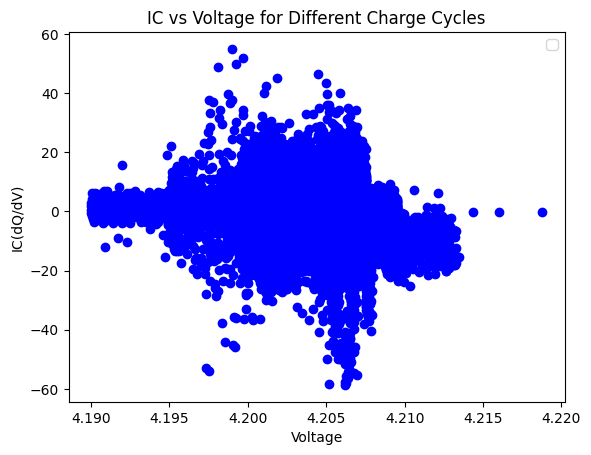

In [45]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for cycle in set(chcycle):
    # Filter data for the current cycle
    cycle_IC = [ic for ic, c in zip(chIC, chcycle) if c == cycle]
    cycle_voltage = [v for v, c in zip(chVol, chcycle) if c == cycle]
    # each cycle has diff colour print the label for first,middle,and last cycle only
    if cycle == 1 or cycle == len(set(chcycle))/2 or cycle == len(set(chcycle)):
        ax.plot(cycle_voltage, cycle_IC, 'bo')
    else:
        ax.plot(cycle_voltage, cycle_IC,'bo')
ax.set_xlabel('Voltage')
ax.set_ylabel('IC(dQ/dV)')
ax.set_title('IC vs Voltage for Different Charge Cycles')
ax.legend()
plt.show()


In [55]:
print((cmap))

<ipython-input-50-250339e85170>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20')  # Choose a colormap with many colors


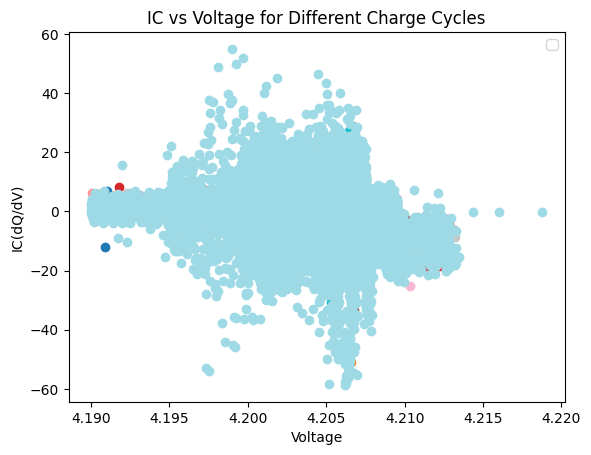

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots()
cmap = cm.get_cmap('tab20')  # Choose a colormap with many colors

# Generate a list of colors for each cycle
colors = [cmap(i) for i in range(len(set(chcycle)))]

for cycle, color in zip(set(chcycle), colors):
    # Filter data for the current cycle
    cycle_IC = [ic for ic, c in zip(chIC, chcycle) if c == cycle]
    cycle_voltage = [v for v, c in zip(chVol, chcycle) if c == cycle]
    # Plot each cycle with its assigned color as a scatter plot
    ax.scatter(cycle_voltage, cycle_IC, color=color)

ax.set_xlabel('Voltage')
ax.set_ylabel('IC(dQ/dV)')
ax.set_title('IC vs Voltage for Different Charge Cycles')
ax.legend()
plt.show()


**Extraction of HI from Discharging curve-**

In [ ]:
discurrent = []
disvoltage=[]
distime=[]
disbat_cycle=[]
for temp in range(len(disdf['id_cycle'])):
  disbat_cycle.append(disdf['id_cycle'][temp])
  discurrent.append(disdf['Current_measured'][temp])
  distime.append(disdf['Time'][temp])
  disvoltage.append(disdf['Voltage_measured'][temp])

disIC_V=[]
disIC_HI=[]
disIC_HIV={}
HI3=[]
HI4=[]
dis_cycle=[]
for j in range(len(disdf['id_cycle'])-1):
  if(disbat_cycle[j]==disbat_cycle[j+1]):
    disIC = (discurrent[j]*(distime[j+1]-distime[j]))/(disvoltage[j+1]-disvoltage[j])
    disIC_V.append([disIC,disvoltage[j],disbat_cycle[j]])
    disIC_HI.append(disIC)
    disIC_HIV[disIC]=disvoltage[j]

  else:
    a=max(disIC_HI)
    HI3.append(a)
    HI4.append(disIC_HIV[a])
    dis_cycle.append(disbat_cycle[j])
    disIC_HI=[]
    disIC_HIV={}
try:
  a=max(disIC_HI)
  HI3.append(a)
  HI4.append(disIC_HIV[a])
  dis_cycle.append(disbat_cycle[-1])
  IC_HI=[]
  IC_HIV={}
except:
  pass
print(len(HI3))
print(len(HI4))

168
168


In [ ]:
discycle=[]
disIC=[]
disVol=[]
for i,j,k in disIC_V:
  discycle.append(k)
  disIC.append(i)
  disVol.append(j)

In [ ]:
# uncomment to draw the point scatter IC curve for different Discharge cycles
# import numpy as np
# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 6))
# plt.scatter(disVol,disIC,c=discycle, cmap='jet')  # Color-coded scatter plot
# plt.ylabel('IC(dQ/dV)')
# plt.xlabel('Volatge(v)')
# plt.title('IC curve for different Discharge cycles')
# plt.colorbar()  # Add a colorbar to indicate the third attribute
# plt.grid(True)
# plt.show()

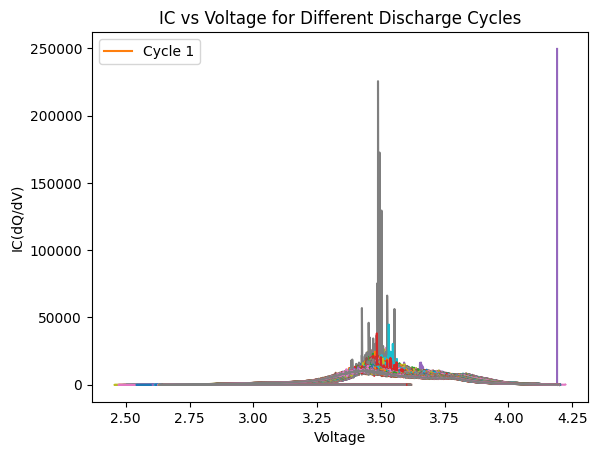

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for cycle in set(discycle):
    # Filter data for the current cycle
    cycle_IC = [ic for ic, c in zip(disIC, discycle) if c == cycle]
    cycle_voltage = [v for v, c in zip(disVol, discycle) if c == cycle]
    # each cycle has diff colour print the label for first,middle,and last cycle only
    if cycle == 1 or cycle == len(set(discycle))/2 or cycle == len(set(discycle)):
        ax.plot(cycle_voltage, cycle_IC, label=f'Cycle {cycle}')
    else:
        ax.plot(cycle_voltage, cycle_IC)

ax.set_xlabel('Voltage')
ax.set_ylabel('IC(dQ/dV)')
ax.set_title('IC vs Voltage for Different Discharge Cycles')
ax.legend()
plt.show()


In [ ]:
print(len(HI1))
print(len(HI2))
print(len(HI3))
print(len(HI4))
print(len(HI5))
print(len(HI6))
print(len(current))
print(len(voltage))
print(len(temperature))

a=min(len(HI1),len(HI2),len(HI3),len(HI4),len(HI5),len(HI6))
print(a)

168
168
168
168
168
168
168
168
168
168


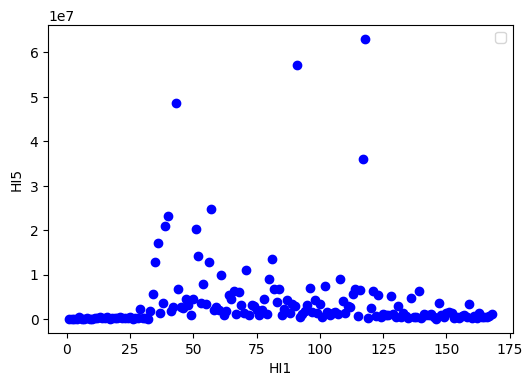

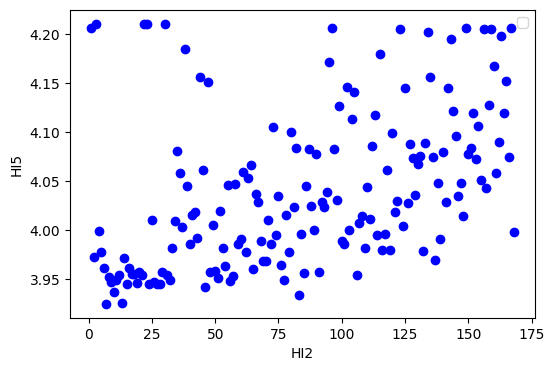

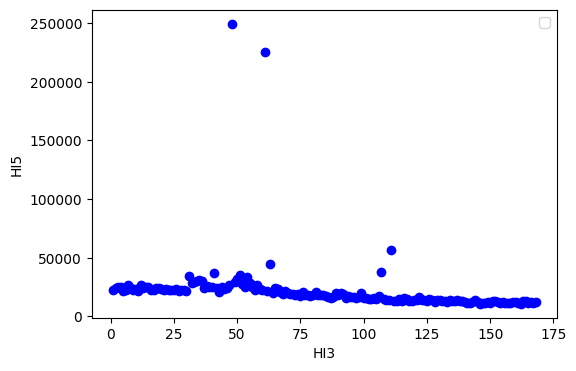

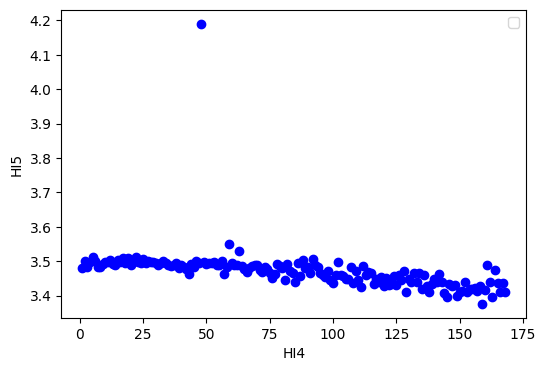

In [ ]:
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI5,HI1[:a], 'bo')

ax.set(xlabel='HI1', ylabel='HI5')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI5,HI2[:a], 'bo')

ax.set(xlabel='HI2', ylabel='HI5')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI5,HI3[:a], 'bo')
ax.set(xlabel='HI3', ylabel='HI5')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI5,HI4[:a],  'bo')
ax.set(xlabel='HI4', ylabel='HI5')
plt.legend()


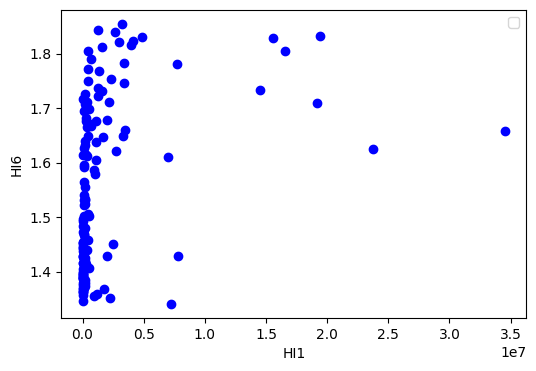

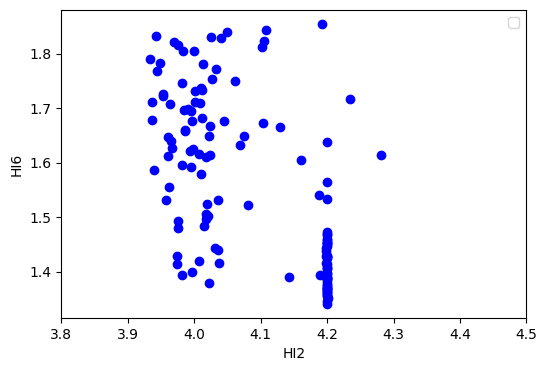

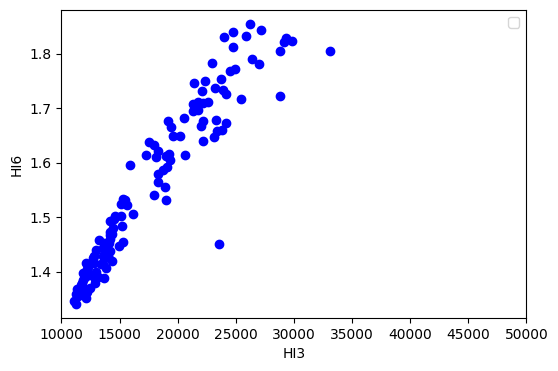

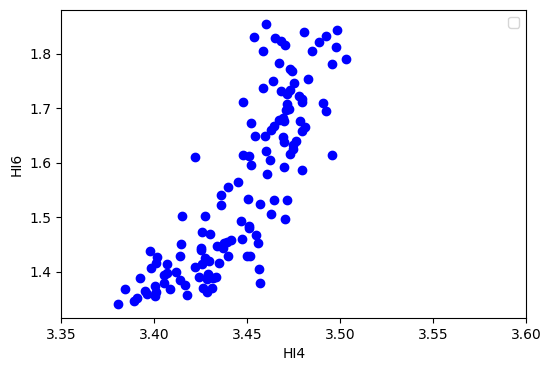

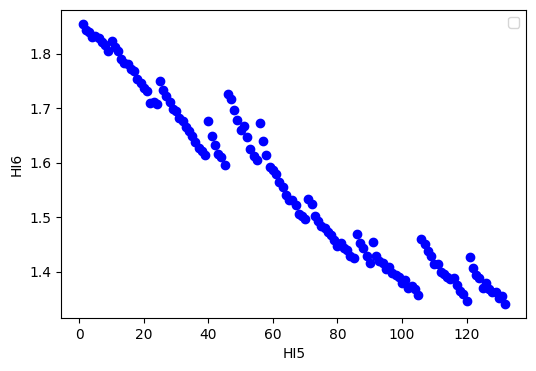

In [ ]:
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI1[:a],HI6, 'bo')

ax.set(xlabel='HI1', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI2[:a],HI6, 'bo')
plt.xlim(3.8,4.5)
ax.set(xlabel='HI2', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI3[:a],HI6, 'bo')
plt.xlim(10000, 50000)
ax.set(xlabel='HI3', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI4[:a],HI6,  'bo')
plt.xlim(3.35,3.6)
ax.set(xlabel='HI4', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI5[:a],HI6, 'bo')
ax.set(xlabel='HI5', ylabel='HI6')
plt.legend()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# Load your original dataset into a DataFrame
original_data = pd.read_csv('/content/B0018_health_index_updated.csv')  # Replace 'your_dataset.csv' with the path to your dataset

# Select the features you want to use for clustering
X = original_data[['cycle', 'capacity', 'IC_C_H', 'IC_C_P', 'IC_D_H', 'IC_D_P']]  # Include all relevant features

# Initialize and fit the K-Means model with k=3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Add the cluster labels to the original dataset
original_data['cluster'] = kmeans.labels_

# Create new attributes based on cluster assignments
original_data['cluster_mean_IC_C_P'] = original_data.groupby('cluster')['IC_C_P'].transform('mean')
original_data['cluster_mean_IC_D_H'] = original_data.groupby('cluster')['IC_D_H'].transform('mean')
original_data['cluster_mean_IC_D_P'] = original_data.groupby('cluster')['IC_D_P'].transform('mean')
original_data['cluster_mean_capacity'] = original_data.groupby('cluster')['capacity'].transform('mean')
# Save the modified dataset with new attributes
original_data.to_csv('B0018_cluster.csv', index=False)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
import csv
B="B0018"
df=pd.read_csv(f"/content/new_{B}_health_index_updated.csv")
df1=pd.read_csv(f"/content/{B}_cluster.csv")
rows = zip(df['cycle'], df['capacity'],df['IC_C_H'],df['IC_C_P'], df['IC_D_H'],df['IC_D_P'],df['check_points'],df1['cluster'])
csv_file = f'{B}_health_index_updated_v2.csv'
# Write the rows to the CSV file
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['cycle', 'capacity', 'IC_C_H', 'IC_C_P','IC_D_H','IC_D_P',"check_points","cluster"])
    # writer.writerow(['cycle', 'capacity', 'current', 'IC_D_H', 'voltage'])  # Write header
    writer.writerows(rows)

print(f"CSV file '{csv_file}' created successfully.")


CSV file 'B0018_health_index_updated_v2.csv' created successfully.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
# data = {
#     'IC_C_H': HI1[:a],
#     'IC_C_P': HI2[:a],
#     'IC_D_H': HI3[:a],
#     'IC_D_P': HI4[:a],
#     'Cycles': HI5[:a],
#     'capacity': HI6[:a],
#     'voltage':voltage[:a],
#     'temperature':temperature[:a],
#     'current':current[:a]
# }

# concatenated_df = pd.DataFrame(data)

# correlation_matrix = concatenated_df.corr()
# # Get the correlation coefficients between 'capacity' and other attributes
# capacity_correlation = correlation_matrix['Cycles'].drop('Cycles')

# # Sort the correlation coefficients in descending order
# sorted_correlation = capacity_correlation.abs().sort_values(ascending=False)

# # Print the sorted correlation coefficients
# print(sorted_correlation)


data=pd.read_csv("/content/B0005_health_index_updated_v3.csv")
corr,_ = pearsonr(data["capacity"],data["IC_C_H"])
print(f"IC_C_H : {corr}")
corr,_ = pearsonr(data["capacity"],data["IC_C_P"])
print(f"IC_C_P : {corr}")
corr,_ = pearsonr(data["capacity"],data["IC_D_H"])
print(f"IC_D_H : {corr}")
corr,_ = pearsonr(data["capacity"],data["IC_D_P"])
print(f"IC_D_P : {corr}")
corr,_ = pearsonr(data["capacity"],data["distance"])
print(f"distance : {corr}")
corr,_ = pearsonr(data["capacity"],data["ratio"])
print(f"clusratioter : {corr}")
corr,_ = pearsonr(data["capacity"],data["moving_average"])
print(f"moving_average : {corr}")
corr,_ = pearsonr(data["capacity"],data["exponential_moving_average"])
print(f"exponential_moving_average : {corr}")



IC_C_H : 0.054242731767040295
IC_C_P : -0.4369000168693604
IC_D_H : 0.30053761034727355
IC_D_P : 0.4752419558843263
distance : 0.9130341185034192
clusratioter : 0.5132018498752997
moving_average : 0.9360802083548089
exponential_moving_average : 0.9975113415214495


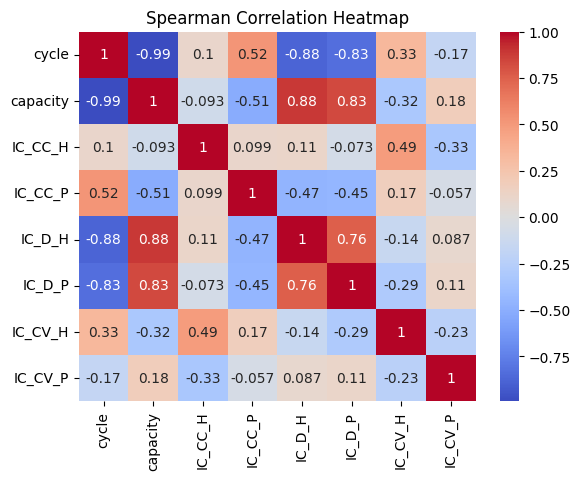

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a random correlation matrix
df = pd.read_csv("/content/B0005_health_index_updated_v1.csv")
corr_matrix = df.corr(method='spearman')

# Create a DataFrame from the correlation matrix
df = pd.DataFrame(corr_matrix, columns=['cycle', 'capacity', 'IC_CC_H', 'IC_CC_P','IC_D_H','IC_D_P','IC_CV_H','IC_CV_P'])

# Create the heatmap
sns.heatmap(df, cmap="coolwarm", annot=True)
plt.title("Spearman Correlation Heatmap")
plt.show()



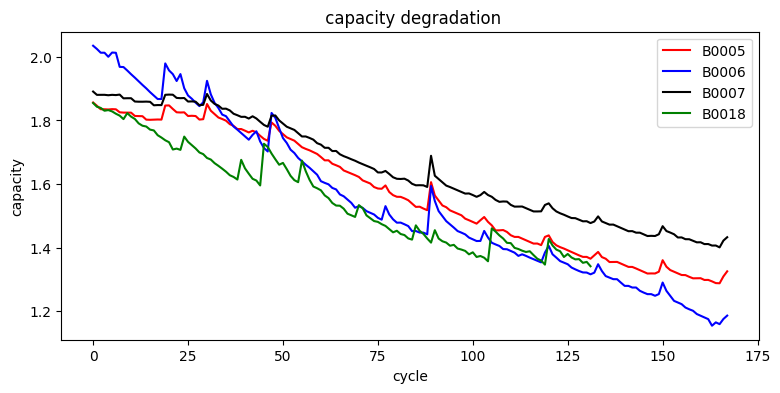

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,4)
df=pd.read_csv("/content/B0005_health_index_updated.csv")
df1=pd.read_csv("/content/B0006_health_index_updated.csv")
df2=pd.read_csv("/content/B0007_health_index_updated.csv")
df3=pd.read_csv("/content/B0018_health_index_updated.csv")

plt.plot(df["capacity"],color='red',label='B0005')
plt.plot(df1["capacity"],color='blue',label='B0006')
plt.plot(df2["capacity"],color='black',label='B0007')
plt.plot(df3["capacity"],color='green',label='B0018')
plt.title(' capacity degradation')
plt.xlabel('cycle')
# plt.ylim(0,2)
plt.ylabel('capacity')
plt.legend()
plt.show()



**Writing all HI's in a CSV file and buildung the LSTM Model-**

In [ ]:
import csv
rows = zip(HI5, HI6,HI1,HI2, HI3,HI4)
csv_file = f'{B}_health_index_updated.csv'
# Write the rows to the CSV file
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['cycle', 'capacity', 'IC_C_H', 'IC_C_P','IC_D_H','IC_D_P'])
    # writer.writerow(['cycle', 'capacity', 'current', 'IC_D_H', 'voltage'])  # Write header
    writer.writerows(rows)

print(f"CSV file '{csv_file}' created successfully.")


CSV file 'B0005_health_index_updated.csv' created successfully.


In [ ]:
final_data

,cycle,capacity,IC_C_H,IC_C_P,IC_D_H,IC_D_P
0,1,1.856487,8.828981e+04,4.206847,22830.110320,3.480996
1,2,1.846327,5.949818e+04,3.971994,24381.926803,3.501615
2,3,1.835349,6.415753e+04,4.210378,24668.755808,3.484151
3,4,1.835263,8.556497e+04,3.998606,25125.648268,3.497942
4,5,1.834646,5.118732e+05,3.977384,21963.459433,3.512115
...,...,...,...,...,...,...
331,164,1.406171,1.170657e+06,4.030477,14313.165094,3.435581
332,165,1.406336,5.788491e+05,4.040319,13408.123045,3.423377
333,166,1.400455,4.403711e+05,4.049108,18511.474054,3.446247
334,167,1.421787,9.463530e+06,4.029699,13113.547999,3.452219


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from keras.optimizers import SGD

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))


## Assuming X_train and X_test are your input data
#X_train = np.reshape(X_train, (X_train.shape[0], 1, 10))
#X_test = np.reshape(X_test, (X_test.shape[0], 1, 10))

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=60, input_shape=(1, 5)))  # Assuming 50 LSTM units
model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=1))
sgd_optimizer = SGD(lr=0.1)

model.compile(loss='mean_squared_error', optimizer=sgd_optimizer)
print(model.summary())


checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")


# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'LSTM_{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60)                15840     
                                                                 
 dense (Dense)               (None, 64)                3904      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 21857 (85.38 KB)
Trainable params: 21857 (85.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/200
318/336 [===========================>..] - ETA: 0s - loss: 0.0766
Epoch 1: val_loss improved from inf to 0.05295, saving model to best_

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


333/336 [============================>.] - ETA: 0s - loss: 0.0463
Epoch 2: val_loss improved from 0.05295 to 0.02966, saving model to best_model.h5
336/336 [==============================] - 2s 6ms/step - loss: 0.0461 - val_loss: 0.0297
Epoch 3/200
316/336 [===========================>..] - ETA: 0s - loss: 0.0233
Epoch 3: val_loss improved from 0.02966 to 0.01600, saving model to best_model.h5
336/336 [==============================] - 1s 4ms/step - loss: 0.0228 - val_loss: 0.0160
Epoch 4/200
325/336 [============================>.] - ETA: 0s - loss: 0.0112
Epoch 4: val_loss improved from 0.01600 to 0.01269, saving model to best_model.h5
336/336 [==============================] - 1s 3ms/step - loss: 0.0109 - val_loss: 0.0127
Epoch 5/200
318/336 [===========================>..] - ETA: 0s - loss: 0.0079
Epoch 5: val_loss improved from 0.01269 to 0.00730, saving model to best_model.h5
336/336 [==============================] - 1s 3ms/step - loss: 0.0078 - val_loss: 0.0073
Epoch 6/200
317/

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from keras.optimizers import SGD

# Load the dataset
dataset = pd.read_csv('/content/B0007.csv')
target_battery = "B0007"

# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:13]  # Assuming health index features are in columns 1 to 12
y = normalized_data[:, 0]   # Number of cycles is in the first column

# Split the dataset into training and testing sets
train_size = int(0.8 * len(dataset))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=60, input_shape=(1, 10)))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1))
sgd_optimizer = SGD(lr=0.1)

model.compile(loss='mean_squared_error', optimizer=sgd_optimizer)
print(model.summary())

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")

# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')

# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'LSTM_{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 60)                17040     
                                                                 
 dense_12 (Dense)            (None, 64)                3904      
                                                                 
 dense_13 (Dense)            (None, 32)                2080      
                                                                 
 dense_14 (Dense)            (None, 1)                 33        
                                                                 
Total params: 23057 (90.07 KB)
Trainable params: 23057 (90.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/200


ValueError: ignored

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'new_{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))


# Build the LSTM model
model = Sequential()
model.add(GRU(units=60, input_shape=(1,6)))  # Assuming 60 GRU units
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

# units = 60,dense_unit=64,dense_unit=32,unit=1-->output layer,epochs=90,batchsize=4
# Train the model
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'GRU_{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_3 (GRU)                 (None, 60)                12240     
                                                                 
 dense_24 (Dense)            (None, 64)                3904      
                                                                 
 dense_25 (Dense)            (None, 32)                2080      
                                                                 
 dense_26 (Dense)            (None, 1)                 33        
                                                                 
Total params: 18257 (71.32 KB)
Trainable params: 18257 (71.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/200
463/468 [============================>.] - ETA: 0s - loss: 0.0284
Epoch 1: val_loss improved from inf to 0.00589, saving model to bes

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


468/468 [==============================] - ETA: 0s - loss: 0.0077
Epoch 2: val_loss did not improve from 0.00589
468/468 [==============================] - 2s 4ms/step - loss: 0.0077 - val_loss: 0.0073
Epoch 3/200
463/468 [============================>.] - ETA: 0s - loss: 0.0072
Epoch 3: val_loss did not improve from 0.00589
468/468 [==============================] - 1s 3ms/step - loss: 0.0071 - val_loss: 0.0095
Epoch 4/200
456/468 [============================>.] - ETA: 0s - loss: 0.0070
Epoch 4: val_loss did not improve from 0.00589
468/468 [==============================] - 1s 3ms/step - loss: 0.0069 - val_loss: 0.0112
Epoch 5/200
468/468 [==============================] - ETA: 0s - loss: 0.0057
Epoch 5: val_loss did not improve from 0.00589
468/468 [==============================] - 1s 3ms/step - loss: 0.0057 - val_loss: 0.0074
Epoch 6/200
468/468 [==============================] - ETA: 0s - loss: 0.0065
Epoch 6: val_loss did not improve from 0.00589
468/468 [======================

In [ ]:
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Attention
from keras.layers import Input
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense,Attention,LSTM
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from keras.optimizers import SGD

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'new_{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))

# Build the LSTM model
attention_input = Input(shape=(1, 6))

# GRU layer
gru_output = LSTM(units=60, return_sequences=True)(attention_input)

# Attention layer
attention = Attention()([gru_output, gru_output])

# Apply attention to GRU output
attended_gru_output = keras.layers.Dot(axes=1)([attention, gru_output])

# Additional layers
dense1 = Dense(units=64, activation='relu')(attended_gru_output)
dense2 = Dense(units=32, activation='relu')(dense1)
output = Dense(units=1)(dense2)

# Create the model
model = Model(inputs=attention_input, outputs=output)

sgd_optimizer = SGD(lr=0.01)

# Compile the model with SGD optimizer
model.compile(loss='mean_squared_error', optimizer=sgd_optimizer)

# Compile the model
print(model.summary())

# units = 60,dense_unit=64,dense_unit=32,unit=1-->output layer,epochs=90,batchsize=4
# Train the model
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'LSTM_attension_{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 1, 6)]               0         []                            
                                                                                                  
 lstm_5 (LSTM)               (None, 1, 60)                16080     ['input_4[0][0]']             
                                                                                                  
 attention_3 (Attention)     (None, 1, 60)                0         ['lstm_5[0][0]',              
                                                                     'lstm_5[0][0]']              
                                                                                                  
 dot_3 (Dot)                 (None, 60, 60)               0         ['attention_3[0][0]',   

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


455/468 [============================>.] - ETA: 0s - loss: 0.0798
Epoch 2: val_loss improved from 0.08520 to 0.08437, saving model to best_model.h5
468/468 [==============================] - 1s 3ms/step - loss: 0.0797 - val_loss: 0.0844
Epoch 3/200
452/468 [===========================>..] - ETA: 0s - loss: 0.0781
Epoch 3: val_loss did not improve from 0.08437
468/468 [==============================] - 2s 4ms/step - loss: 0.0782 - val_loss: 0.0890
Epoch 4/200
460/468 [============================>.] - ETA: 0s - loss: 0.0803
Epoch 4: val_loss improved from 0.08437 to 0.08430, saving model to best_model.h5
468/468 [==============================] - 2s 5ms/step - loss: 0.0800 - val_loss: 0.0843
Epoch 5/200
466/468 [============================>.] - ETA: 0s - loss: 0.0795
Epoch 5: val_loss did not improve from 0.08430
468/468 [==============================] - 2s 4ms/step - loss: 0.0794 - val_loss: 0.0844
Epoch 6/200
448/468 [===========================>..] - ETA: 0s - loss: 0.0772
Epoch 6:

In [ ]:
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Attention
from keras.layers import Input
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense,Attention,LSTM
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from keras.optimizers import SGD

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'new_{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))

# Build the LSTM model
attention_input = Input(shape=(1, 6))

# GRU layer
gru_output = GRU(units=60, return_sequences=True)(attention_input)

# Attention layer
attention = Attention()([gru_output, gru_output])

# Apply attention to GRU output
attended_gru_output = keras.layers.Dot(axes=1)([attention, gru_output])

# Additional layers
dense1 = Dense(units=64, activation='relu')(attended_gru_output)
dense2 = Dense(units=32, activation='relu')(dense1)
output = Dense(units=1)(dense2)

# Create the model
model = Model(inputs=attention_input, outputs=output)

sgd_optimizer = SGD(lr=0.01)

# Compile the model with SGD optimizer
model.compile(loss='mean_squared_error', optimizer=sgd_optimizer)

# Compile the model
print(model.summary())

# units = 60,dense_unit=64,dense_unit=32,unit=1-->output layer,epochs=90,batchsize=4
# Train the model
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'GRU_attension_{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 1, 6)]               0         []                            
                                                                                                  
 gru_4 (GRU)                 (None, 1, 60)                12240     ['input_5[0][0]']             
                                                                                                  
 attention_4 (Attention)     (None, 1, 60)                0         ['gru_4[0][0]',               
                                                                     'gru_4[0][0]']               
                                                                                                  
 dot_4 (Dot)                 (None, 60, 60)               0         ['attention_4[0][0]',   

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


466/468 [============================>.] - ETA: 0s - loss: 0.0794
Epoch 2: val_loss improved from 0.08514 to 0.08471, saving model to best_model.h5
468/468 [==============================] - 1s 3ms/step - loss: 0.0798 - val_loss: 0.0847
Epoch 3/200
457/468 [============================>.] - ETA: 0s - loss: 0.0805
Epoch 3: val_loss did not improve from 0.08471
468/468 [==============================] - 1s 3ms/step - loss: 0.0797 - val_loss: 0.0853
Epoch 4/200
454/468 [============================>.] - ETA: 0s - loss: 0.0798
Epoch 4: val_loss did not improve from 0.08471
468/468 [==============================] - 1s 3ms/step - loss: 0.0795 - val_loss: 0.0850
Epoch 5/200
456/468 [============================>.] - ETA: 0s - loss: 0.0802
Epoch 5: val_loss did not improve from 0.08471
468/468 [==============================] - 1s 3ms/step - loss: 0.0801 - val_loss: 0.0874
Epoch 6/200
454/468 [============================>.] - ETA: 0s - loss: 0.0784
Epoch 6: val_loss did not improve from 0.08

In [ ]:
import csv
B="B0018"
import pandas as pd
df=pd.read_csv(f"/content/{B}_health_index_updated_d1.csv")
df1=pd.read_csv(f"/content/{B}_health_index_updated_v2.csv")
rows = zip(df['cycle'], df['capacity'],df['IC_CV_H'],df['IC_C_P'], df['IC_D_H'],df['IC_D_P'],df1['cluster'],df1['check_points'])
csv_file = f'{B}_health_index_updated_d2.csv'
# Write the rows to the CSV file
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['cycle', 'capacity', 'IC_CV_H', 'IC_CV_D','IC_D_H','IC_D_P','cluster','check_points'])
    # writer.writerow(['cycle', 'capacity', 'current', 'IC_D_H', 'voltage'])  # Write header
    writer.writerows(rows)

print(f"CSV file '{csv_file}' created successfully.")

CSV file 'B0018_health_index_updated_d2.csv' created successfully.


In [ ]:
target_battery="B0018"
model="d2"

In [ ]:
import pandas as pd
final_data=pd.DataFrame()
three_battries=input()
print("target battery")
target_battery=input()
for i in three_battries.split(","):
  final_data = pd.concat([final_data, pd.read_csv(f'{i}_health_index_updated_d1.csv')], ignore_index=True)

final_data.to_csv("final.csv")

B0005,B0006,B0007
target battery
B0018


In [ ]:
!pip install autokeras
import autokeras as ak
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Attention
from keras.layers import Input
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense,Attention,LSTM
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Load the training and validation datasets
# Load the dataset
dataset = final_data
# # Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# # Split the dataset into training and testing sets
df=pd.read_csv(f'{target_battery}_health_index_updated_d2.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target


# Reshape the input data for LSTM [samples, time steps, features]
# X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
# X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))


# Create an AutoKeras regression model

clf=ak.StructuredDataRegressor(

    loss="mean_squared_error",
    metrics=None,
    project_name="structured_data_regressor",
    max_trials=10,
    objective="val_loss"
)


# Train the model on the training dataset
clf.fit( x=X_train, y=y_train, epochs=200, callbacks=None, validation_split=0.1, validation_data=(X_test, y_test),batch_size=1)




# Make predictions on the validation dataset
train_loss = clf.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = clf.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


train_predictions = clf.predict(X_train)
test_predictions =clf.predict(X_test)
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'autokeras_{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()


Trial 10 Complete [00h 00m 31s]
val_loss: 0.07109629362821579

Best val_loss So Far: 0.022558066993951797
Total elapsed time: 00h 06m 57s
Epoch 1/200
300/300 [==============================] - 3s 6ms/step - loss: 0.1824 - mean_squared_error: 0.1824 - val_loss: 0.0920 - val_mean_squared_error: 0.0920
Epoch 2/200
300/300 [==============================] - 1s 4ms/step - loss: 0.0517 - mean_squared_error: 0.0517 - val_loss: 0.0788 - val_mean_squared_error: 0.0788
Epoch 3/200
300/300 [==============================] - 1s 3ms/step - loss: 0.0378 - mean_squared_error: 0.0378 - val_loss: 0.0840 - val_mean_squared_error: 0.0840
Epoch 4/200
300/300 [==============================] - 1s 3ms/step - loss: 0.0305 - mean_squared_error: 0.0305 - val_loss: 0.0785 - val_mean_squared_error: 0.0785
Epoch 5/200
300/300 [==============================] - 1s 3ms/step - loss: 0.0261 - mean_squared_error: 0.0261 - val_loss: 0.0700 - val_mean_squared_error: 0.0700
Epoch 6/200
300/300 [==========================

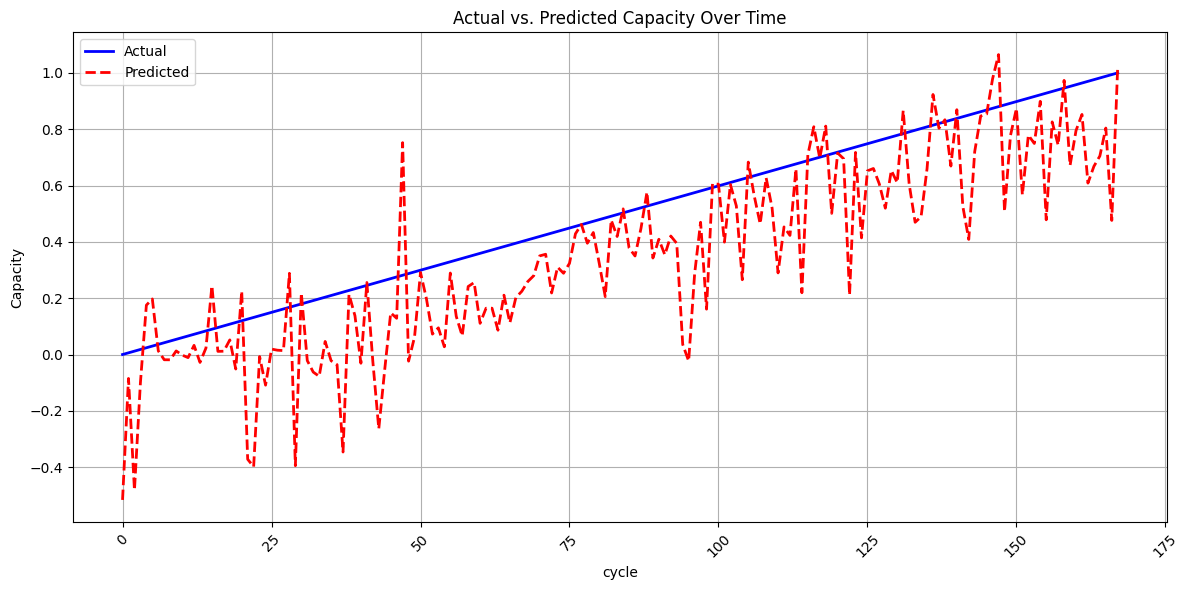

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' contains your original dataset and 'y_pred' contains the predicted values

# Extract the 'trade_date' column as the time axis

# Create a new figure
plt.figure(figsize=(12, 6))

  # Set the x-axis limits from 1 to 5
  # Set the y-axis limits from 10 to 30

# Plot the actual "close" values
plt.plot( y_test, label='Actual', color='blue', linewidth=2)

# print(time_axis)
# print(y_pred)
# Plot the predicted "close" values
plt.plot(test_rul_predictions, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('cycle')
plt.ylabel('Capacity')
plt.title('Actual vs. Predicted Capacity Over Time')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
!pip install tpot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 877.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stopit: filename=stopit-1.1.2-py3-none-any.whl size=11937 sha256=9718c64c81090beadb722147eefa9808564f154d0b460ce977345775d34a5b05
  Stored in directory: /root/.cache/pip/wheels/af/f9/87/bf5b3d565c2a007b4dae9d8142dccc85a9f164e517062dd519
Successfully built stopit


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Replace 'your_dataset.csv' with the actual file name
data = final_data
# # Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(data)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

df=pd.read_csv(f'{target_battery}_health_index_updated_d1.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Assuming 'capacity' is your target variable, and the rest are features
target = data['capacity']
features = data.drop(columns=['capacity'])
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np


# Create and configure the TPOTRegressor
tpot = TPOTRegressor(generations=3, population_size=20, random_state=42, verbosity=3)

# Fit TPOT to the training data
tpot.fit(X_train, y_train)

# Make predictions on the test data
y_pred = tpot.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE) and then RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Evaluate the best model on the test data
r2 = tpot.score(X_test, y_test)

r2_scr = r2_score(y_test, y_pred)

print("R-squared score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 score:",r2_scr)


with open(f'tpot_{target_battery}.txt','w') as f:
  f.write(f'Testing MAE: {mae}\n')
  f.write(f'Testing RMSE: {rmse}\n')
  f.write(f'Testing R^2 score: {r2}\n')
f.close()



30 operators have been imported by TPOT.


Optimization Progress:   0%|          | 0/80 [00:00<?, ?pipeline/s]

_pre_test decorator: _mate_operator: num_test=0 'str' object has no attribute 'arity'.
_pre_test decorator: _random_mutation_operator: num_test=0 Unsupported set of arguments: The combination of penalty='l2' and loss='epsilon_insensitive' are not supported when dual=False, Parameters: penalty='l2', loss='epsilon_insensitive', dual=False.

Generation 1 - Current Pareto front scores:

-1	-0.012206623917053067	RidgeCV(input_matrix)
_pre_test decorator: _mate_operator: num_test=0 'str' object has no attribute 'arity'.
_pre_test decorator: _mate_operator: num_test=0 'str' object has no attribute 'arity'.
_pre_test decorator: _random_mutation_operator: num_test=0 Automatic alpha grid generation is not supported for l1_ratio=0. Please supply a grid by providing your estimator with the appropriate `alphas=` argument..
_pre_test decorator: _mate_operator: num_test=0 'str' object has no attribute 'arity'.

Generation 2 - Current Pareto front scores:

-1	-0.012206623917053067	RidgeCV(input_matrix

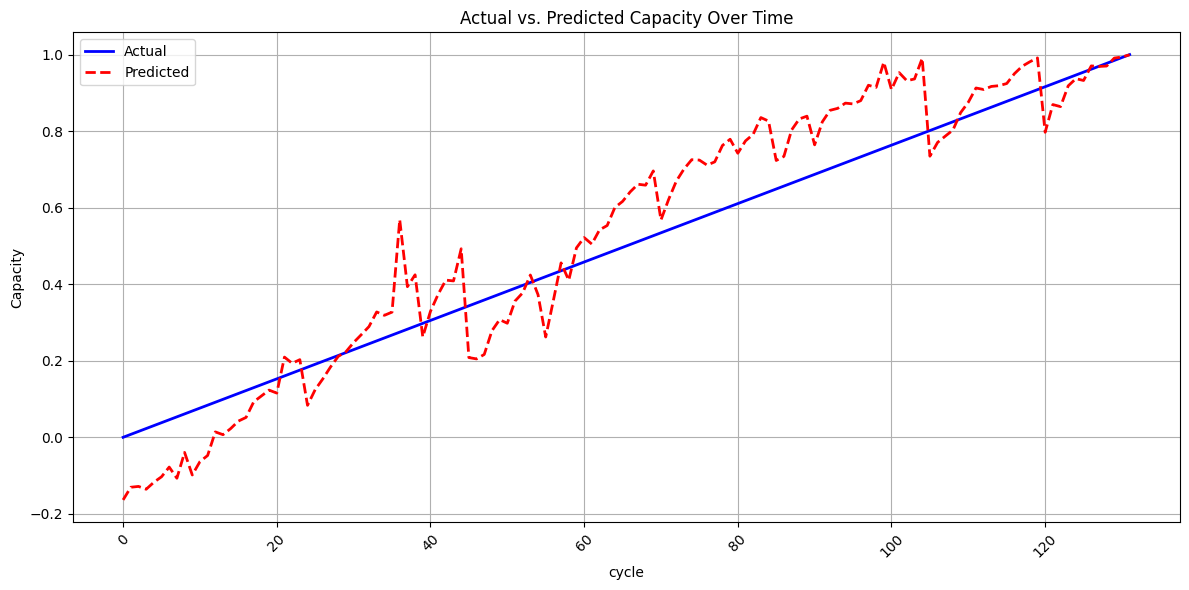

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' contains your original dataset and 'y_pred' contains the predicted values

# Extract the 'trade_date' column as the time axis

# Create a new figure
plt.figure(figsize=(12, 6))

  # Set the x-axis limits from 1 to 5
  # Set the y-axis limits from 10 to 30

# Plot the actual "close" values
plt.plot( y_test, label='Actual', color='blue', linewidth=2)

# print(time_axis)
# print(y_pred)
# Plot the predicted "close" values
plt.plot(y_pred, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('cycle')
plt.ylabel('Capacity')
plt.title('Actual vs. Predicted Capacity Over Time')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
!pip install h2o

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.3/265.3 MB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for h2o: filename=h2o-3.44.0.2-py2.py3-none-any.whl size=265363806 sha256=462ba67458e530f7861121a70268cb2495f853c0ea5038c79a435daeb11150ca
  Stored in directory: /root/.cache/pip/wheels/e9/ea/ab/889709967692e30c57c46137edd2cae6b2768bb65ec7cb8aa5
Successfully built h2o


In [ ]:
import h2o
from h2o.automl import H2OAutoML
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

# Initialize H2O cluster

h2o.init()
# Load your dataset
data =h2o.import_file(f"final.csv")
data1 = h2o.import_file(f"/content/{target_battery}_health_index_updated_d2.csv")
target = "capacity"
target1 = "capacity"


# Split the data into training and testing sets
train, test = data.split_frame(ratios=[0.9])

# Define the predictor columns (features)
predictors = [col for col in data.columns if col != target]

predictors1 = [col for col in data1.columns if col != target1]


a = len(data)
X_train, X_test=predictors,predictors1
y_train, y_test=target,target1

# Train the AutoML model
aml = H2OAutoML(max_runtime_secs=60)  # You can adjust the maximum runtime
aml.train(x=X_train, y=y_train, training_frame=train)

# Get the leader model
leader = aml.leader

# Make predictions on the test data
y_predictions = leader.predict(test)

# Evaluate model performance
performance = leader.model_performance(test)

# Calculate the requested metrics
rmse = performance.rmse()
mae = performance.mae()
mse = performance.mse()
r2 = performance.r2()

# Print the performance metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")

with open(f'H20_{target_battery}.txt','w') as f:
  f.write(f'Testing mse: {mse}\n')
  f.write(f'Testing MAE: {mae}\n')
  f.write(f'Testing RMSE: {rmse}\n')
  f.write(f'Testing R^2 score: {r2}\n')
f.close()


# Shutdown H2O cluster
h2o.cluster().shutdown()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.21" 2023-10-17; OpenJDK Runtime Environment (build 11.0.21+9-post-Ubuntu-0ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.21+9-post-Ubuntu-0ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.10/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp5j_0nchp
  JVM stdout: /tmp/tmp5j_0nchp/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp5j_0nchp/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,06 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.44.0.2
H2O_cluster_version_age:,1 month and 3 days
H2O_cluster_name:,H2O_from_python_unknownUser_23zi8v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Root Mean Squared Error (RMSE): 0.01294142935454901
Mean Absolute Error (MAE): 0.010700050691541955
Mean Squared Error (MSE): 0.00016748059373878285
R-squared (R^2): 0.9943846401852099
H2O session _sid_9143 closed.


/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from nested sequences exceeding the maximum number of dimensions of 32 is deprecated. If you mean to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


ValueError: ignored

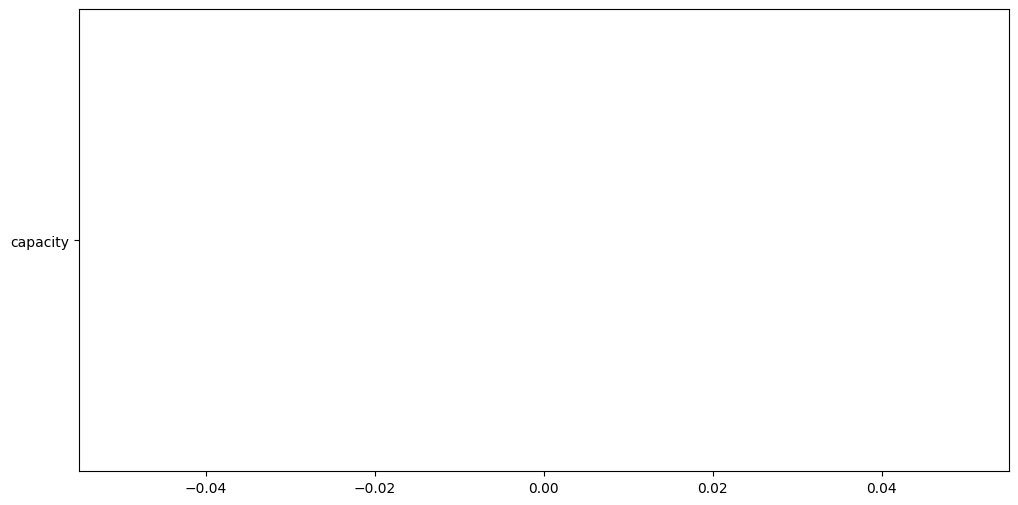

In [ ]:
import matplotlib.pyplot as plt


# Create a new figure
plt.figure(figsize=(12, 6))
# Plot the actual "close" values
plt.plot( y_test, label='Actual', color='blue', linewidth=2)

# print(time_axis)
# print(y_pred)
# Plot the predicted "close" values
plt.plot(y_predictions, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('cycle')
plt.ylabel('Capacity')
plt.title('Actual vs. Predicted Capacity Over Time')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()


Training MAE: 0.052834372544885475
Testing MAE: 0.09361046589626612
Training RMSE: 0.06828030886257433
Testing RMSE: 0.12752039409545418
Training R^2 score: 0.9447156807156771
Testing R^2 score: 0.8077969862336192


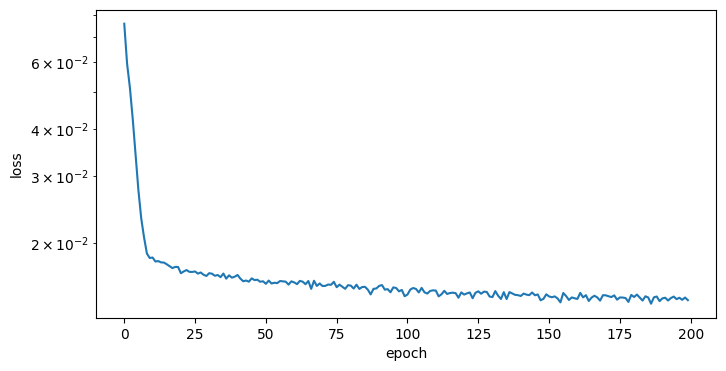

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8,4)
plt.figure()
plt.ylabel('loss'); plt.xlabel('epoch')
plt.semilogy(history.history['loss'])

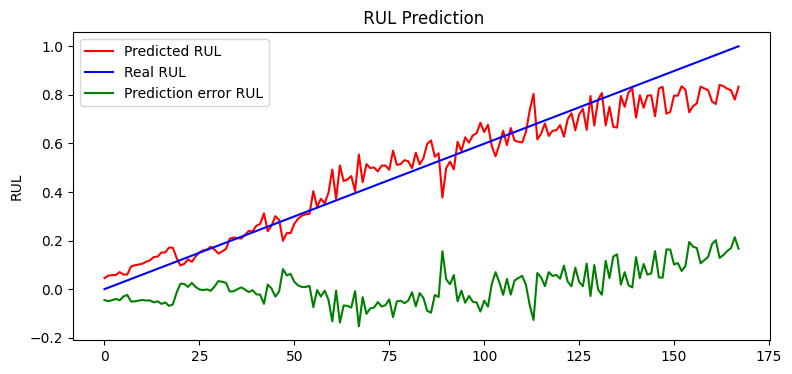

In [ ]:
# Denormalizing number of cycle leads to inconsistency, so plot on this value
#Visualization
test_capacity=list(dataset['capacity'])
plt.rcParams["figure.figsize"] = (9,4)
plt.plot(test_rul_predictions,color='red',label='Predicted RUL')
plt.plot(y_test,color='blue',label='Real RUL')
plt.plot(y_test-test_rul_predictions,color='green',label='Prediction error RUL')
plt.title(' RUL Prediction')
# plt.xlabel('capacity')
# plt.ylim(0,2)
plt.ylabel('RUL')
plt.legend()
plt.show()



In [ ]:
!pip install ruptures

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.3 MB/s eta 0:00:00


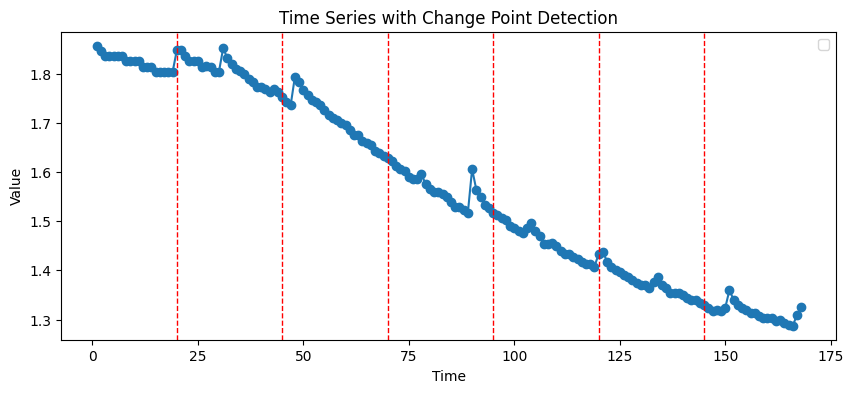

In [ ]:
import ruptures as rpt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def detect_change_points(time_series1, time_series2, model="rbf"):

    # Convert the input data to NumPy arrays
    time_series1 = np.array(time_series1)
    time_series2 = np.array(time_series2)
    combined_series = np.concatenate((time_series1, time_series2))

    # Create a change point detection model with subsegmentation
    algo = rpt.Pelt(model=model, min_size=5).fit(combined_series)

    # Detect change points
    change_points = algo.predict(pen=2)  # You can adjust the 'pen' parameter for precision

    # Separate the change points based on the lengths of the input time series
    change_points = [cp for cp in change_points if cp <= len(time_series1)]

    return change_points

# Example usage:
df= pd.read_csv("/content/B0005_health_index_updated.csv")
time_series1 = df["cycle"]
time_series2 = df["capacity"]

change_points = detect_change_points(time_series1, time_series2)

# Create a plot to visualize the change points
plt.figure(figsize=(10, 4))
plt.plot(time_series1, time_series2, marker='o')

# Highlight the regions with change points
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--', linewidth=1)

plt.legend()
plt.title("Time Series with Change Point Detection")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


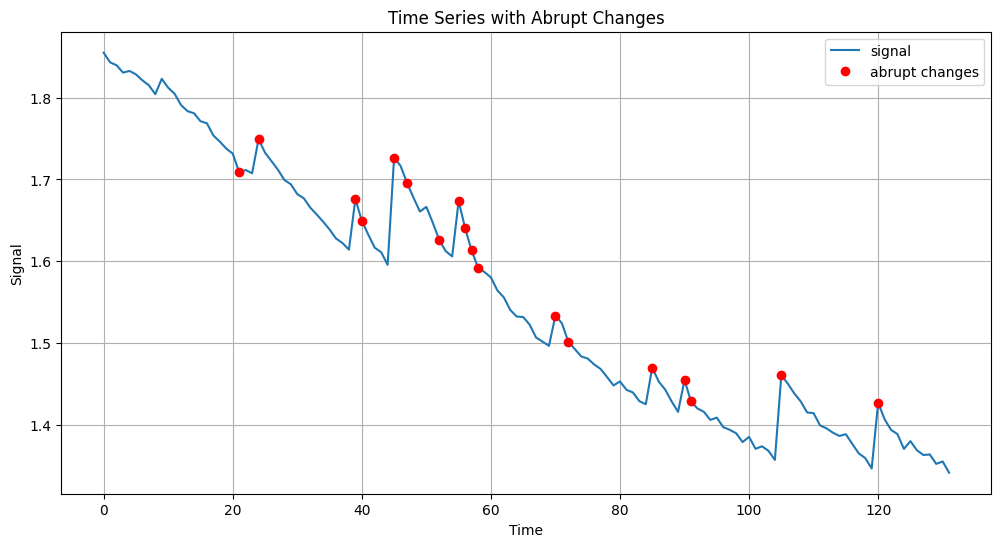

In [ ]:
import pandas as pd

def detect_abrupt_changes(signal, percent_change, max_time_interval):
    """
    Detect abrupt changes in a time series signal based on the specified parameters.

    Parameters:
        signal (pandas.Series): One-dimensional time series signal.
        percent_change (float): The minimum percentage change in the signal range that is considered an abrupt change.
        max_time_interval (int): The maximum time interval in samples between two data points to be considered part of the same change.

    Returns:
        pandas.Series: A boolean mask indicating the positions of the abrupt changes in the input signal.
    """
    # Calculate the absolute change in the signal.
    abs_change = abs(signal.diff())

    # Calculate the threshold for the minimum change required to be considered an abrupt change.
    change_threshold = (signal.max() - signal.min()) * percent_change

    # Initialize a mask of False values to indicate no abrupt changes have been detected yet.
    abrupt_changes = pd.Series(False, index=signal.index)

    # Loop over each data point in the signal.
    for i in range(1, len(signal)):
        # If the absolute change is greater than the threshold, mark this data point as the start of an abrupt change.
        if abs_change[i] >= change_threshold:
            abrupt_changes[i] = True

            # Keep track of the end of the current change.
            end_of_change = i

            # Continue checking subsequent data points to see if they are still part of the same change.
            for j in range(i+1, min(i+max_time_interval, len(signal))):
                if abs_change[j] >= change_threshold:
                    # If the change is still above the threshold, mark this data point as part of the same change.
                    abrupt_changes[j] = True

                    # Update the end of the current change.
                    end_of_change = j
                else:
                    # If the change has fallen below the threshold, stop checking subsequent data points.
                    break

            # Skip checking data points that are already part of the current change.
            i = end_of_change

    return abrupt_changes



import matplotlib.pyplot as plt
df= pd.read_csv("/content/B0018_health_index_updated.csv")
signal = df["capacity"]

# Plot the time series
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(signal, label='signal')

# Plot the abrupt changes
abrupt_changes = detect_abrupt_changes(signal, 0.04, 10)
abrupt_changes = abrupt_changes.astype(int)
ax.plot(signal[abrupt_changes==1], 'ro', label='abrupt changes')

# Add labels, grid, and legend
ax.set_xlabel('Time')
ax.set_ylabel('Signal')
ax.set_title('Time Series with Abrupt Changes')
ax.legend()
ax.grid(True)

# Show the plot
plt.show()

In [ ]:
change_points=[]
for i in range(len(abrupt_changes)):
  if abrupt_changes[i]==1:
    change_points.append(i)

average=[]
distance=[]
for i in range(len(signal)):
  nearest=0
  k=63456
  for j in change_points:
    if k>=abs(j-i):
      k=abs(j-i)
      nearest=j
  if k==0:
    average.append(0)
    distance.append(0)
  else:
    distan=abs(signal[i]-signal[j])
    ratio=abs(signal[i]-signal[j])/k
    average.append(ratio)
    distance.append(distan)

print(average)


[0.02038865423550559, 0.02081763749317672, 0.021724161083688326, 0.022435045702818943, 0.02387396618214713, 0.025105381422448406, 0.026290560514955204, 0.027737659199847404, 0.02903502078856158, 0.033021454036579835, 0.03502568819818953, 0.03778488563663125, 0.04044461866009229, 0.04457849262455771, 0.05058511866937227, 0.057394376304538954, 0.06835752356504865, 0.08169692458656203, 0.10645898659868165, 0.15541097592995468, 0.3046738917021192, 0, 0.2846271752227467, 0.28065935548179843, 0, 0.30592693289753137, 0.14769427549188663, 0.09500117237975488, 0.06810626332030567, 0.05343877241576926, 0.04250998767189074, 0.03573346857112918, 0.034097164114632754, 0.03839161262295735, 0.0442762747367881, 0.05298184198831546, 0.0669353029602473, 0.09765546021352789, 0.18716386920129424, 0, 0, 0.2055402100126258, 0.09478659502855669, 0.0920300279897367, 0.1686210875241012, 0, 0.2897246098975108, 0, 0.25093553723379136, 0.11690795396597742, 0.11978407281864112, 0.21999083559531618, 0, 0.1853149593

In [ ]:
ma=[]
for i in range(len(signal)-2):
  a=(signal[i]+signal[i+1]+signal[i+2])/3
  ma.append(a)

a=(signal[len(signal)-2]+signal[len(signal)-1])/3
ma.append(a)
a=signal[len(signal)-1]/3
ma.append(a)
print(ma)


[1.8459339649785411, 1.8378236595469153, 1.8343252179579046, 1.83063423201427, 1.8274767603721322, 1.8216333616059197, 1.8135564174366283, 1.8141894310081714, 1.8131745448022454, 1.8133057401739159, 1.8025537800078737, 1.793002236946666, 1.7850845617197637, 1.7785394583485648, 1.7735926839581584, 1.7644899731783728, 1.7561602071679765, 1.745838318512865, 1.738467049631489, 1.7259254655666725, 1.7171938733542849, 1.7091890279475113, 1.7227367669438323, 1.7298366861687604, 1.734746418002752, 1.7222824488523207, 1.7111151556468844, 1.701716926011909, 1.6917357289759354, 1.6843054712148293, 1.6748009001226905, 1.6665641500248236, 1.6569798479201687, 1.64806225430378, 1.6382143320181122, 1.629524180932484, 1.621269681348495, 1.637403989587247, 1.6464529696804735, 1.6525784166175839, 1.6326998687709555, 1.619900600528535, 1.6075942263656937, 1.6443580490934224, 1.6795795670661018, 1.713032796307408, 1.6967230893052385, 1.6780868553167199, 1.6682826454464739, 1.6579677449003152, 1.64633617926

In [ ]:
def calculate_ema(data, n):
    ema = [data[0]]  # Initial EMA is the first data point
    smoothing_factor = 2 / (n + 1)

    for i in range(1, len(data)):
        ema_today = (data[i] * smoothing_factor) + (ema[i - 1] * (1 - smoothing_factor))
        ema.append(ema_today)

    return ema
ema=calculate_ema(signal,10)
print(ema)

[1.8550045207910817, 1.8528574318670665, 1.8504473246976985, 1.8468521028428815, 1.8442790308608967, 1.8414153679052134, 1.8377400627533187, 1.8336364169151382, 1.828302168766343, 1.82735636176963, 1.824587087270706, 1.8209697328963552, 1.8154923905127078, 1.8096702691180202, 1.8044463315567565, 1.7984031875778368, 1.7929899534129041, 1.7858336855545056, 1.7786311502975973, 1.771182710917193, 1.7639707041227184, 1.7539023923635078, 1.7461874041279992, 1.739153719255138, 1.7409872623789353, 1.7394931628087642, 1.736354648267032, 1.7318985847611585, 1.7259657211912545, 1.7201604344154464, 1.713204484135694, 1.7066176800825437, 1.6991459074580617, 1.6915180074808156, 1.6836463980351044, 1.6754870801739445, 1.6667891911834465, 1.658673647745096, 1.6505523756181255, 1.6551886010407322, 1.6541180631337262, 1.6501662319927015, 1.6440298210672242, 1.6380067332049904, 1.630271667053095, 1.6478054439681256, 1.6603076162908255, 1.6667650600731272, 1.668767470801514, 1.6672931469789514, 1.66713274

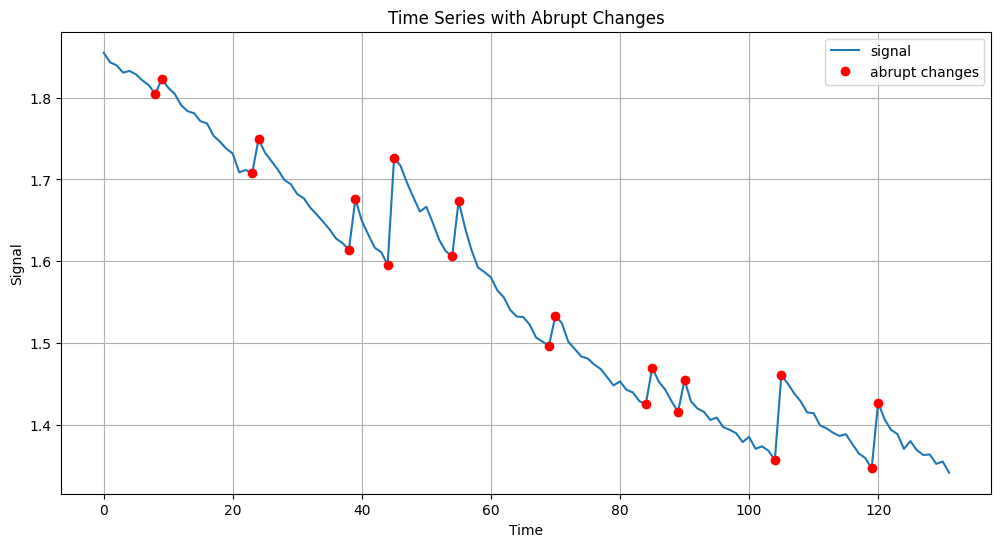

In [13]:
import pandas as pd

def detect_abrupt_changes(signal, percent_change,max_num):

    # Calculate the threshold for the minimum change required to be considered an abrupt change.
    change_threshold = (signal.max() - signal.min()) * percent_change

    # Initialize a mask of False values to indicate no abrupt changes have been detected yet.
    abrupt_changes = pd.Series(False, index=signal.index)

    # Loop over each data point in the signal.
    for i in range(1, len(signal)):
      # if abs(signal[i]-signal[i-1])>=change_threshold:
      #   abrupt_changes[i]=True
      if i > max_num and (i+max_num)<(len(signal)-1):
        max_id=0
        min_id=685465
        for j in range(i-max_num,i+max_num):
          max_id = max(max_id,signal[j])
          min_id = min(min_id,signal[j])
        if signal[i]>=max_id:
          abrupt_changes[i] = True
        if signal[i]<=min_id:
          abrupt_changes[i] = True

    return abrupt_changes



import matplotlib.pyplot as plt
df= pd.read_csv("/content/B0018_health_index_updated.csv")
signal = df["capacity"]

# Plot the time series
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(signal, label='signal')

# Plot the abrupt changes
abrupt_changes = detect_abrupt_changes(signal, 0.035,3)
abrupt_changes = abrupt_changes.astype(int)
ax.plot(signal[abrupt_changes==1], 'ro', label='abrupt changes')

# Add labels, grid, and legend
ax.set_xlabel('Time')
ax.set_ylabel('Signal')
ax.set_title('Time Series with Abrupt Changes')
ax.legend()
ax.grid(True)

# Show the plot
plt.show()

In [ ]:
import csv
rows = zip(df["cycle"], df["capacity"],df["IC_C_H"],df["IC_C_P"], df["IC_D_H"],df["IC_D_P"],distance,average,ma,ema)
csv_file = f'B0018_health_index_updated_v3.csv'
# Write the rows to the CSV file
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['cycle', 'capacity', 'IC_C_H', 'IC_C_P','IC_D_H','IC_D_P','distance','ratio','moving_average','exponential_moving_average'])
    # writer.writerow(['cycle', 'capacity', 'current', 'IC_D_H', 'voltage'])  # Write header
    writer.writerows(rows)

print(f"CSV file '{csv_file}' created successfully.")


CSV file 'B0018_health_index_updated_v3.csv' created successfully.


In [ ]:
import numpy as np
import pandas as pd

def z_score(data):
    mean = data.mean()
    std = data.std()
    return (data - mean) / std


if __name__ == "__main__":
    # Load the data using Pandas
    df = pd.read_csv("/content/B0005_health_index_updated.csv")
    data = df["capacity"]
    z_scores = z_score(data)
    print(z_scores)


0      1.491420
1      1.438061
2      1.380407
3      1.379952
4      1.376711
         ...   
163   -1.465440
164   -1.494115
165   -1.497009
166   -1.383766
167   -1.299402
Name: capacity, Length: 168, dtype: float64


In [8]:
import numpy as np

df = pd.read_csv("/content/B0006_health_index_updated_d1.csv")
data = df["capacity"]


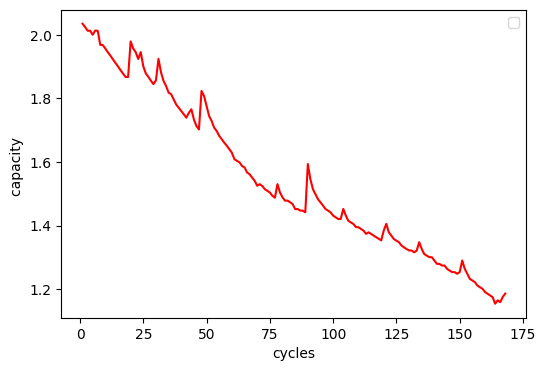

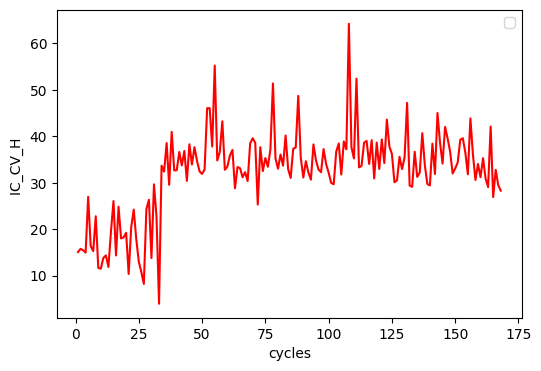

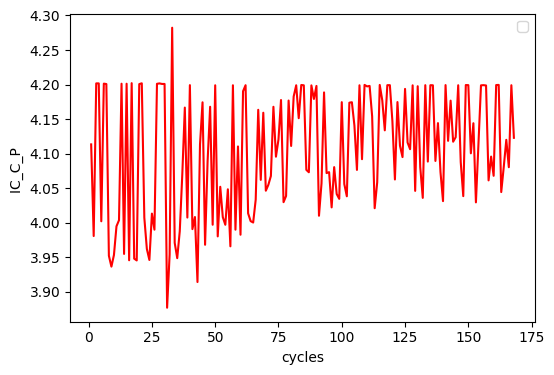

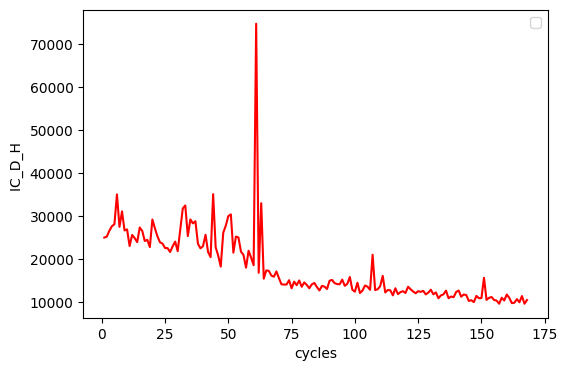

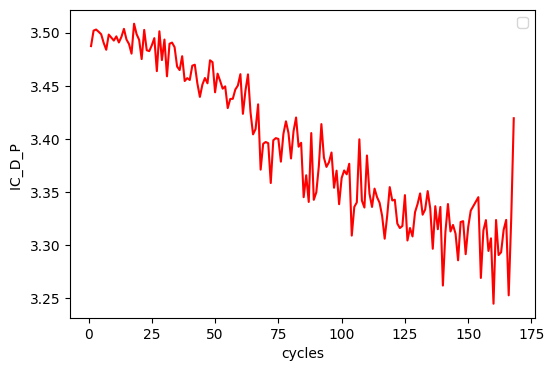

In [9]:
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(df['cycle'],df['capacity'], 'r-')
ax.set(xlabel='cycles', ylabel='capacity ')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(df['cycle'],df['IC_CV_H'], 'r-')
ax.set(xlabel='cycles', ylabel='IC_CV_H ')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(df['cycle'],df['IC_C_P'], 'r-')
ax.set(xlabel='cycles', ylabel='IC_C_P ')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(df['cycle'],df['IC_D_H'], 'r-')
ax.set(xlabel='cycles', ylabel='IC_D_H ')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(df['cycle'],df['IC_D_P'], 'r-')
ax.set(xlabel='cycles', ylabel='IC_D_P ')
plt.legend()


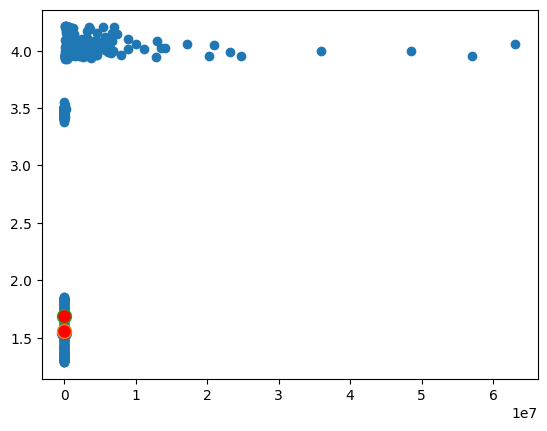

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans2
import pandas as pd

def kmeans_clustering(data, k):
  """Performs K-means clustering on the given data.

  Args:
    data: A numpy array of data with dimensions [n_samples, n_features].
    k: The number of clusters.

  Returns:
    A list of labels, where each label is the cluster index of the corresponding data point.
  """

  # Reshape the data to have two dimensions.

  # Convert the data to type float.
  data = data.astype(np.float32)

  # Perform K-means clustering.
  centroids, labels = kmeans2(data, k)

  return centroids,labels

def plot_clusters(data, labels, centroids):
  """Plots the data points and cluster centroids."""

  # Create a scatter plot of the data points.
  plt.scatter(data[:, 0], data[:, 1])

  # Plot the cluster centroids.
  for centroid in centroids:
    plt.plot(centroid[0], centroid[1], 'o', markersize=10, markerfacecolor='red')

  # Show the plot.
  plt.show()

if __name__ == '__main__':
  # Read the data from the CSV file.
  data = pd.read_csv("/content/B0005_health_index_updated.csv")
  data = data.to_numpy()

  # Perform K-means clustering with k=2.
  centroids,labels = kmeans_clustering(data, k=3)

  # Plot the clusters.
  plot_clusters(data.reshape(-1,2), labels, centroids)


In [ ]:
!pip install autots

In [ ]:
import pandas as pd
final_data=pd.DataFrame()
three_battries=input()
print("target battery")
target_battery=input()
for i in three_battries.split(","):
  final_data = pd.concat([final_data, pd.read_csv(f'{i}_health_index_updated_d2.csv')], ignore_index=True)

B0018
target battery
khb


In [ ]:
from autots import AutoTS, load_daily
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# sample datasets can be used in either of the long or wide import shapes
data = final_data

a=len(data)
train_data=data[:int(0.9*a)]
validation_data=data[int(0.9*a):]
b=len(validation_data)
model = AutoTS(
    forecast_length=b,
    frequency='infer',
    prediction_interval=0.9,
    ensemble='auto',
    model_list="default",
    transformer_list="default",
    drop_most_recent=1,
    max_generations=3,
    num_validations=2,
    validation_method="backwards"
)
model = model.fit(
    train_data,
    date_col='cycle' ,
    value_col='capacity',
)

prediction = model.predict()


y_true = data['capacity'].values[-len(prediction.forecast):]  # True values
y_pred = prediction.forecast.values  # Predicted values
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE: {rmse}")

r2 = r2_score(y_true, y_pred)

print(f"r2_score: {r2}")

# Print the details of the best model
print(model)

# point forecasts dataframe
forecasts_df = prediction.forecast
# upper and lower forecasts
forecasts_up, forecasts_low = prediction.upper_forecast, prediction.lower_forecast

# accuracy of all tried model results
model_results = model.results()
# and aggregated from cross validation
validation_results = model.results("validation")

Data frequency is: N, used frequency is: N
Model Number: 1 with model ARIMA in generation 0 of 3
Model Number: 2 with model AverageValueNaive in generation 0 of 3
Model Number: 3 with model AverageValueNaive in generation 0 of 3
Model Number: 4 with model AverageValueNaive in generation 0 of 3
Model Number: 5 with model DatepartRegression in generation 0 of 3
Model Number: 6 with model DatepartRegression in generation 0 of 3
Model Number: 7 with model DatepartRegression in generation 0 of 3
Model Number: 8 with model DatepartRegression in generation 0 of 3


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Epoch 1/50
4/4 [==============================] - 6s 13ms/step - loss: 0.3794
Epoch 2/50
4/4 [==============================] - 0s 9ms/step - loss: 0.3798
Epoch 3/50
4/4 [==============================] - 0s 9ms/step - loss: 0.3762
Epoch 4/50
4/4 [==============================] - 0s 8ms/step - loss: 0.3760
Epoch 5/50
4/4 [==============================] - 0s 8ms/step - loss: 0.3781
Epoch 6/50
4/4 [==============================] - 0s 8ms/step - loss: 0.3775
Epoch 7/50
4/4 [==============================] - 0s 9ms/step - loss: 0.3772
Epoch 8/50
4/4 [==============================] - 0s 8ms/step - loss: 0.3765
Epoch 9/50
4/4 [==============================] - 0s 9ms/step - loss: 0.3764
Epoch 10/50
4/4 [==============================] - 0s 9ms/step - loss: 0.3777
Epoch 11/50
4/4 [==============================] - 0s 9ms/step - loss: 0.3774
Epoch 12/50
4/4 [==============================] - 0s 8ms/step - loss: 0.3771
Epoch 13/50
4/4 [==============================] - 0s 9ms/step - loss: 0

1/1 [==============================] - 1s 783ms/step
Model Number: 9 with model ETS in generation 0 of 3
Model Number: 10 with model ETS in generation 0 of 3
Model Number: 11 with model GLM in generation 0 of 3
Model Number: 12 with model GLM in generation 0 of 3
Model Number: 13 with model GLS in generation 0 of 3
Model Number: 14 with model GLS in generation 0 of 3
Model Number: 15 with model GluonTS in generation 0 of 3
Template Eval Error: ImportError('GluonTS installation is incompatible with AutoTS. The numpy version is sometimes the issue, try 1.23.1 {as of 06-2023}') in model 15 in generation 0: GluonTS
Model Number: 16 with model GluonTS in generation 0 of 3
Template Eval Error: ImportError('GluonTS installation is incompatible with AutoTS. The numpy version is sometimes the issue, try 1.23.1 {as of 06-2023}') in model 16 in generation 0: GluonTS
Model Number: 17 with model GluonTS in generation 0 of 3
Template Eval Error: ImportError('GluonTS installation is incompatible with

/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:236: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:247: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


...

52 - WindowRegression with avg smape 2.23: 
Model Number: 53 of 86 with model LastValueNaive for Validation 2
53 - LastValueNaive with avg smape 1.77: 
Model Number: 54 of 86 with model GLS for Validation 2


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


54 - GLS with avg smape 2.66: 
Model Number: 55 of 86 with model GLS for Validation 2
55 - GLS with avg smape 2.66: 
Model Number: 56 of 86 with model AverageValueNaive for Validation 2
56 - AverageValueNaive with avg smape 2.83: 
Model Number: 57 of 86 with model AverageValueNaive for Validation 2
57 - AverageValueNaive with avg smape 2.23: 
Model Number: 58 of 86 with model MultivariateMotif for Validation 2
📈 58 - MultivariateMotif with avg smape 0.86: 
Model Number: 59 of 86 with model UnobservedComponents for Validation 2
59 - UnobservedComponents with avg smape 2.23: 
Model Number: 60 of 86 with model LastValueNaive for Validation 2
60 - LastValueNaive with avg smape 2.84: 
Model Number: 61 of 86 with model ARDL for Validation 2
61 - ARDL with avg smape 2.21: 
Model Number: 62 of 86 with model NVAR for Validation 2
62 - NVAR with avg smape 5.45: 
Model Number: 63 of 86 with model NVAR for Validation 2
63 - NVAR with avg smape 2.62: 
Model Number: 64 of 86 with model SectionalMoti

/usr/local/lib/python3.10/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


77 - SeasonalNaive with avg smape 4.05: 
Model Number: 78 of 86 with model GLM for Validation 2
78 - GLM with avg smape 2.23: 
Model Number: 79 of 86 with model DatepartRegression for Validation 2
79 - DatepartRegression with avg smape 2.23: 
Model Number: 80 of 86 with model DatepartRegression for Validation 2
80 - DatepartRegression with avg smape 2.23: 
Model Number: 81 of 86 with model GLM for Validation 2
81 - GLM with avg smape 6.86: 
Model Number: 82 of 86 with model FBProphet for Validation 2
82 - FBProphet with avg smape 2.23: 
Model Number: 83 of 86 with model ARIMA for Validation 2
83 - ARIMA with avg smape 3.45: 
Model Number: 84 of 86 with model WindowRegression for Validation 2
84 - WindowRegression with avg smape 2.38: 
Model Number: 85 of 86 with model AverageValueNaive for Validation 2
85 - AverageValueNaive with avg smape 1.72: 
Model Number: 86 of 86 with model AverageValueNaive for Validation 2
86 - AverageValueNaive with avg smape 6.16: 
Model Number: 744 with mode

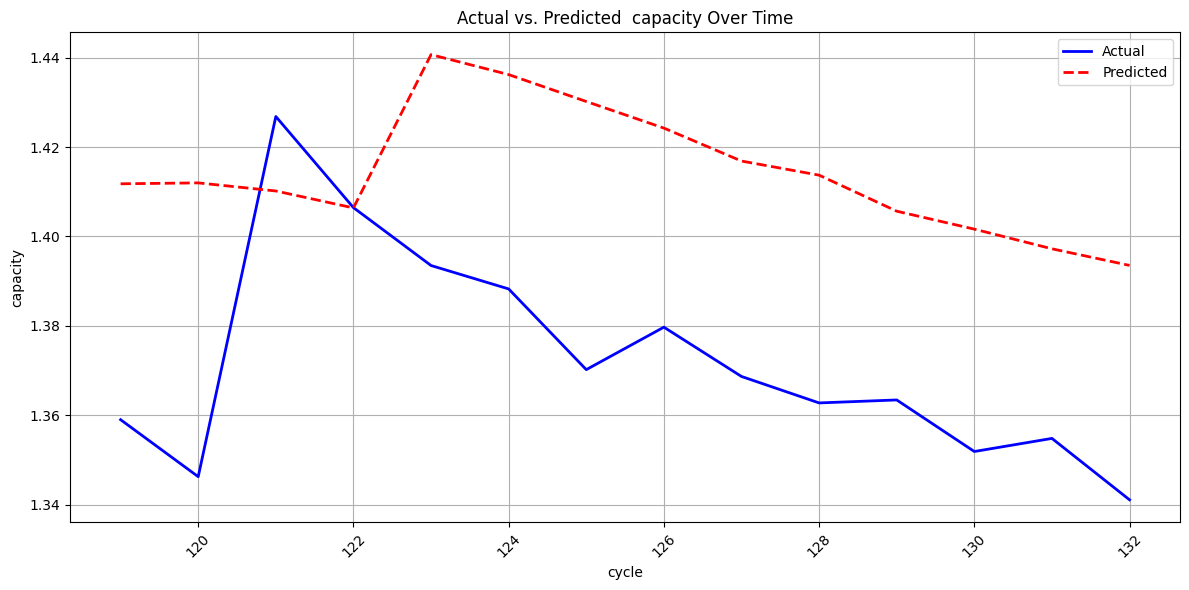

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' contains your original dataset and 'y_pred' contains the predicted values

# Extract the 'trade_date' column as the time axis
time_axis = validation_data['cycle']
pred=prediction.forecast
# Create a new figure
plt.figure(figsize=(12, 6))

  # Set the x-axis limits from 1 to 5
  # Set the y-axis limits from 10 to 30

# Plot the actual "close" values
plt.plot(time_axis, validation_data['capacity'], label='Actual', color='blue', linewidth=2)

# print(time_axis)
# print(y_pred)
# Plot the predicted "close" values
plt.plot(time_axis, pred, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('cycle')
plt.ylabel('capacity')
plt.title('Actual vs. Predicted  capacity Over Time')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
!pip list


Package                          Version
-------------------------------- ---------------------
absl-py                          1.4.0
aiohttp                          3.8.6
aiosignal                        1.3.1
alabaster                        0.7.13
albumentations                   1.3.1
altair                           4.2.2
anyio                            3.7.1
appdirs                          1.4.4
argon2-cffi                      23.1.0
argon2-cffi-bindings             21.2.0
array-record                     0.4.1
arviz                            0.15.1
astropy                          5.3.4
astunparse                       1.6.3
async-timeout                    4.0.3
atpublic                         4.0
attrs                            23.1.0
audioread                        3.0.1
autograd                         1.6.2
autots                           0.6.1
Babel                            2.13.0
backcall                         0.2.0
beautifulsoup4                   4.11.2
bi

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


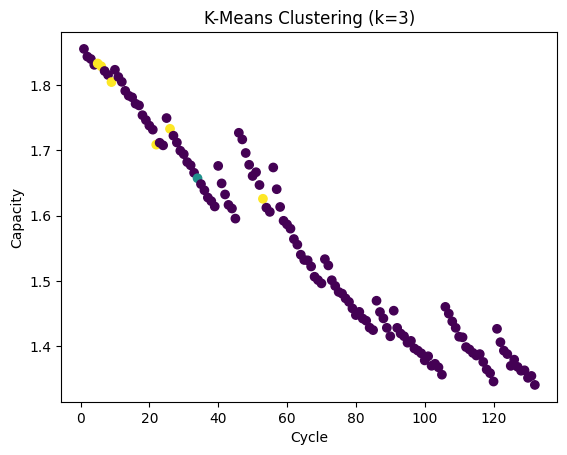

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load your dataset into a DataFrame
data = pd.read_csv('/content/B0018_health_index_updated.csv')  # Replace 'your_dataset.csv' with the path to your dataset

# Select the features you want to use for clustering
X = data[['cycle', 'capacity', 'IC_C_H', 'IC_C_P', 'IC_D_H', 'IC_D_P']]

# Initialize and fit the K-Means model with k=3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Add the cluster labels to your dataset
data['cluster'] = kmeans.labels_

# Create a scatter plot of the data points, color-coded by cluster
plt.scatter(X['cycle'], X['capacity'], c=data['cluster'], cmap='viridis')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('K-Means Clustering (k=3)')

# Show the plot
plt.show()

In [ ]:
import numpy as np

def find_change_points(data, threshold):
    """
    Detect change points in a list using Cumulative Sum (CUSUM) method.

    Args:
    data (list): Input data as a list.
    threshold (float): Threshold for change point detection.

    Returns:
    change_points (list): List of detected change points.
    """
    data = np.array(data)
    mean = np.mean(data)
    cumulative_sum = np.cumsum(data - mean)
    print(cumulative_sum)
    change_points = []
    current_cp = None
    for i, c in enumerate(cumulative_sum):
        if c > threshold:
            if current_cp is None:
                print(i)
                current_cp = i
        elif current_cp is not None:
            change_points.append((current_cp, i - 1))
            current_cp = None

    if current_cp is not None:
        change_points.append((current_cp, len(data) - 1))

    return change_points

# Example usage:

df= pd.read_csv("/content/B0005_health_index_updated.csv")
input_data = df["capacity"]
threshold_value = 3  # Adjust this threshold as needed.

change_points = find_change_points(input_data, threshold_value)

for start, end in change_points:
    print(f"Change detected from index {start} to {end}")

# You can customize the threshold_value and the input_data list as needed.


[2.83985357e-01 5.57810542e-01 8.20657672e-01 1.08341814e+00
 1.34556158e+00 1.60872117e+00 1.87136525e+00 2.12461998e+00
 2.37689177e+00 2.62900297e+00 2.88112046e+00 3.12282033e+00
 3.36407043e+00 3.60500885e+00 3.83510479e+00 4.06470963e+00
 4.29478707e+00 4.52535332e+00 4.75562888e+00 5.03015281e+00
 5.30506805e+00 5.56874341e+00 5.82202209e+00 6.07463367e+00
 6.32771311e+00 6.56924218e+00 6.81150931e+00 7.05297663e+00
 7.28324023e+00 7.51481521e+00 7.79411569e+00 8.05231748e+00
 8.29971952e+00 8.53652542e+00 8.76863326e+00 8.99550826e+00
 9.21144943e+00 9.42187041e+00 9.62240207e+00 9.82293776e+00
 1.00183078e+01 1.02081208e+01 1.04032360e+01 1.05934023e+01
 1.07726308e+01 1.09419783e+01 1.11055676e+01 1.13266895e+01
 1.15373765e+01 1.17322386e+01 1.19167544e+01 1.20911229e+01
 1.22603381e+01 1.24242585e+01 1.25780782e+01 1.27213827e+01
 1.28594140e+01 1.29929264e+01 1.31207354e+01 1.32428132e+01
 1.33552140e+01 1.34571861e+01 1.35592533e+01 1.36504676e+01
 1.37369794e+01 1.381833

In [ ]:
import numpy as np
from scipy.cluster.vq import kmeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



def kmeans_clustering(data, k):

  # Perform K-means clustering.
  centroids, labels = kmeans(data, k)

  return labels

if __name__ == '__main__':
  # Get the input data.

  dataset = pd.read_csv("/content/B0005_health_index_updated.csv")
  # Normalize the dataset
  scaler = MinMaxScaler(feature_range=(0, 1))
  normalized_data = scaler.fit_transform(dataset)


  data = normalized_data

  # Perform K-means clustering with k=2.
  labels = kmeans_clustering(data, k=3)

  # Print the cluster labels.
  print(labels)


0.279337104040584


In [ ]:
from sklearn.preprocessing import MinMaxScaler
dataset = pd.read_csv("/content/B0005_health_index_updated.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)
print(normalized_data.shape)

(168, 6)


In [ ]:
import pandas as pd

# Sample DataFrame (replace this with your actual DataFrame)
data = {
    'ts_code': [601988, 601988, 601988, 601988, 601988, 601988, 601988, 601988],
    'trade_date': [20070104, 20070105, 20070108, 20070109, 20070110, 20070111, 20070112, 20070115],
    'open': [5.69, 5.3, 4.87, 5.06, 5.25, 5.07, 4.88, 4.71],
    'high': [5.97, 5.34, 5.14, 5.19, 5.29, 5.07, 4.97, 5.0],
    'low': [5.37, 5.07, 4.83, 4.95, 5.05, 4.9, 4.7, 4.65],
    'close': [5.63, 5.07, 5.08, 5.18, 5.1, 4.93, 4.73, 4.99]
}

df = pd.DataFrame(data)

# Convert trade_date to datetime format
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')

# Print the DataFrame with the updated trade_date format
print(df)


   ts_code trade_date  open  high   low  close
0   601988 2007-01-04  5.69  5.97  5.37   5.63
1   601988 2007-01-05  5.30  5.34  5.07   5.07
2   601988 2007-01-08  4.87  5.14  4.83   5.08
3   601988 2007-01-09  5.06  5.19  4.95   5.18
4   601988 2007-01-10  5.25  5.29  5.05   5.10
5   601988 2007-01-11  5.07  5.07  4.90   4.93
6   601988 2007-01-12  4.88  4.97  4.70   4.73
7   601988 2007-01-15  4.71  5.00  4.65   4.99


In [ ]:
!git clone https://github.com/IntelligentSystemsLab/TWAFR-GRU

Cloning into 'TWAFR-GRU'...
remote: Enumerating objects: 87, done.
remote: Total 87 (delta 0), reused 0 (delta 0), pack-reused 87
Receiving objects: 100% (87/87), 8.89 MiB | 12.32 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
import os
os.mkdir("./result")
os.mkdir("./model")

In [ ]:
!python main.py

1 round training.
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:1102: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:982.)
  result = _VF.gru(input, hx, self._flat_weights, self.bias, self.num_layers,
2 round training.
3 round training.
4 round training.
5 round training.
0 Fine Tuning!
1 Fine Tuning!
2 Fine Tuning!
3 Fine Tuning!
4 Fine Tuning!
6 round training.
7 round training.
8 round training.
9 round training.
10 round training.
0 Fine Tuning!
1 Fine Tuning!
2 Fine Tuning!
3 Fine Tuning!
4 Fine Tuning!
11 round training.
12 round training.
13 round training.
14 round training.
15 round training.
0 Fine Tuning!
1 Fine Tuning!
2 Fine Tuning!
3 Fine Tuning!
4 Fine Tuning!
16 round training.
17 round training.
18 round traini

In [ ]:
import zipfile
import os

def add_folder_to_zip(zip_file, folder_path):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            zip_file.write(file_path, os.path.relpath(file_path, folder_path))

parent_folder = "/content/result"  # Path to the parent folder

with zipfile.ZipFile("result.zip", "w") as zip_file:
    add_folder_to_zip(zip_file, parent_folder)
